# EDA: House Listings, Kings County

# Question to answer

Hypothesis that I want to check:

- Houses in the city cost more than the suburbs
- Bigger the house, more expensive it is
- The house sales are not season dependent

**My client**
*William Rodriguez* 
- Buyer 
- 2 people, 
- country (best timing & non-renovated) & 
- city house (fast & central location), (wants two houses)

# 1. Initial Analysis

### 1. Importing all modules and setiing things up**

In [1]:
import warnings

warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns
import missingno as msno
from io import StringIO # creates an in-memory file-like object that behaves like a file, but stores its contents in a string instead of on disk.
from scipy import stats # for stat analysis
from matplotlib.ticker import PercentFormatter   # Import formatter to display axis values as percentages
from scipy.cluster import hierarchy
import folium
from folium import plugins
from selenium import webdriver
from selenium.webdriver.chrome.options import Options
import time
from folium.plugins import MarkerCluster


# Update default Matplotlib settings for consistent plot appearance
plt.rcParams.update({
    "figure.figsize": (8, 5),      # Set default figure size
    "axes.facecolor": "white",     # Set plot background color
    "axes.edgecolor": "black"      # Set border color of the plot area
})

plt.rcParams["figure.facecolor"] = "w"            # Set overall figure background to white

pd.plotting.register_matplotlib_converters()      # Enable pandas datetime converters for Matplotlib plots

# Set pandas option to format floating-point numbers to 3 decimal places when displayed
pd.set_option('display.float_format', lambda x: '%.3f' % x)


In [3]:
print("\n## 1. Initial Data Inspection")
print("\n")

# importing data
df_eda = pd.read_csv('../eda.csv')
print(df_eda.head(5))

# make a copy of the file for further steps
# Make a copy of the DataFrame
df_eda_copy = df_eda.copy()


## 1. Initial Data Inspection


         date      price          id  bedrooms  bathrooms  sqft_living  \
0  2014-10-13 221900.000  7129300520     3.000      1.000     1180.000   
1  2014-12-09 538000.000  6414100192     3.000      2.250     2570.000   
2  2015-02-25 180000.000  5631500400     2.000      1.000      770.000   
3  2014-12-09 604000.000  2487200875     4.000      3.000     1960.000   
4  2015-02-18 510000.000  1954400510     3.000      2.000     1680.000   

   sqft_lot  floors  waterfront  view  ...  grade  sqft_above  sqft_basement  \
0  5650.000   1.000         NaN 0.000  ...      7    1180.000          0.000   
1  7242.000   2.000       0.000 0.000  ...      7    2170.000        400.000   
2 10000.000   1.000       0.000 0.000  ...      6     770.000          0.000   
3  5000.000   1.000       0.000 0.000  ...      7    1050.000        910.000   
4  8080.000   1.000       0.000 0.000  ...      8    1680.000          0.000   

   yr_built  yr_renovated  zipcode    lat

In [4]:
print(f"Dataset shape: {df_eda_copy.shape}")
print(f"Number of properties: {len(df_eda_copy)}")
print(f"Date range: {df_eda_copy['date'].min()} to {df_eda_copy['date'].max()}")
print("\n")

print("=== DATA TYPES AND BASIC INFO ===")
# check for data types and statistics overview of data frame columns
print(df_eda_copy.info())

# check data types in data frame
df_eda_copy.dtypes

Dataset shape: (21597, 21)
Number of properties: 21597
Date range: 2014-05-02 to 2015-05-27


=== DATA TYPES AND BASIC INFO ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21597 entries, 0 to 21596
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           21597 non-null  object 
 1   price          21597 non-null  float64
 2   id             21597 non-null  int64  
 3   bedrooms       21597 non-null  float64
 4   bathrooms      21597 non-null  float64
 5   sqft_living    21597 non-null  float64
 6   sqft_lot       21597 non-null  float64
 7   floors         21597 non-null  float64
 8   waterfront     19206 non-null  float64
 9   view           21534 non-null  float64
 10  condition      21597 non-null  int64  
 11  grade          21597 non-null  int64  
 12  sqft_above     21597 non-null  float64
 13  sqft_basement  21145 non-null  float64
 14  yr_built       21597 non-null  int64  
 15  yr_renovat

date              object
price            float64
id                 int64
bedrooms         float64
bathrooms        float64
sqft_living      float64
sqft_lot         float64
floors           float64
waterfront       float64
view             float64
condition          int64
grade              int64
sqft_above       float64
sqft_basement    float64
yr_built           int64
yr_renovated     float64
zipcode            int64
lat              float64
long             float64
sqft_living15    float64
sqft_lot15       float64
dtype: object

### 2. Data Cleaning and Preparation
- Identify columns and adjust them
- Missing value imputation

In [5]:
print("\n## 2. Data Cleaning and Preparation")

# Step 1: Identify columns with missing values (NaN or empty string in this case).
    # The initial df.info() showed non-null counts, let's look for empty strings/NaN explicitly.
    # We'll replace empty strings with NaN for proper imputation/handling.
df_eda_copy = df_eda_copy.replace('', np.nan)

# Check missing values BEFORE imputation
print("=== MISSING VALUES BEFORE IMPUTATION ===")

# display number of missing values per column
    ## df.isna(): This returns a DataFrame of the same shape as df, but with boolean values:
    ## True → the cell is missing (NaN, None, or NaT)
    ## False → the cell is not missing
print(df_eda_copy.isnull().sum())
print("\n")

df_eda_copy.isna().sum()  * 100 / len(df_eda_copy) # * 100 / len(df) gives the percentage of data missing

# For numerical columns (sqft_basement, yr_renovated):
    ## Use median or mode imputation
    ## For yr_renovated, 0 typically means "never renovated"

# For categorical/ordinal columns (waterfront, view):
    ## Use mode (most frequent value) imputation

    ## For waterfront, likely impute with 0 (not waterfront)
    ## For view, impute with 0 (no view)


## 2. Data Cleaning and Preparation
=== MISSING VALUES BEFORE IMPUTATION ===
date                0
price               0
id                  0
bedrooms            0
bathrooms           0
sqft_living         0
sqft_lot            0
floors              0
waterfront       2391
view               63
condition           0
grade               0
sqft_above          0
sqft_basement     452
yr_built            0
yr_renovated     3848
zipcode             0
lat                 0
long                0
sqft_living15       0
sqft_lot15          0
dtype: int64




date             0.000
price            0.000
id               0.000
bedrooms         0.000
bathrooms        0.000
sqft_living      0.000
sqft_lot         0.000
floors           0.000
waterfront      11.071
view             0.292
condition        0.000
grade            0.000
sqft_above       0.000
sqft_basement    2.093
yr_built         0.000
yr_renovated    17.817
zipcode          0.000
lat              0.000
long             0.000
sqft_living15    0.000
sqft_lot15       0.000
dtype: float64

*Why Imputation over Interpolation:*

Non-temporal data: Your dataset isn't time-series data where interpolation makes sense. The dates are sale dates, not sequential measurements of the same property.

Categorical nature: Some missing fields like waterfront (likely 0/1) and view (ordinal scale 0-4) are categorical/ordinal, not continuous.

Small dataset: With only 25 records and few missing values, interpolation could introduce unnecessary complexity.

Missing pattern: The missing values are sporadic across different records and columns, not following a pattern that interpolation would help.

In [6]:
# Step 2: Impute numerical columns
# For sqft_basement: assuming missing values mean no basement (0 sqft)
df_eda_copy['sqft_basement'].fillna(0, inplace=True)

# For yr_renovated: assuming missing values mean never renovated (0)
df_eda_copy['yr_renovated'].fillna(0, inplace=True)

# Impute categorical columns  
# For waterfront: most properties are not waterfront, so impute with 0
df_eda_copy['waterfront'].fillna(0, inplace=True)

# For view: most properties have no view, so impute with 0
df_eda_copy['view'].fillna(0, inplace=True)

# Check missing values AFTER imputation
print("=== MISSING VALUES AFTER IMPUTATION ===")
print(df_eda_copy.isnull().sum())

=== MISSING VALUES AFTER IMPUTATION ===
date             0
price            0
id               0
bedrooms         0
bathrooms        0
sqft_living      0
sqft_lot         0
floors           0
waterfront       0
view             0
condition        0
grade            0
sqft_above       0
sqft_basement    0
yr_built         0
yr_renovated     0
zipcode          0
lat              0
long             0
sqft_living15    0
sqft_lot15       0
dtype: int64


In [7]:
# Step 3: correcting data types
# Convert the 'date' column to datetime objects.
df_eda_copy['date'] = pd.to_datetime(df_eda_copy['date'])

# Drop the 'id' column as it is an arbitrary identifier and has no predictive power.
df_corrected = df_eda_copy.drop('id', axis=1)

# Correct the data types for 'floors', 'waterfront', and 'view' to be integers.
df_corrected['floors'] = df_corrected['floors'].astype(float).astype(int)
df_corrected['waterfront'] = df_corrected['waterfront'].astype(int)
df_corrected['view'] = df_corrected['view'].astype(float).astype(int)

print(df_corrected.dtypes)

date             datetime64[ns]
price                   float64
bedrooms                float64
bathrooms               float64
sqft_living             float64
sqft_lot                float64
floors                    int64
waterfront                int64
view                      int64
condition                 int64
grade                     int64
sqft_above              float64
sqft_basement           float64
yr_built                  int64
yr_renovated            float64
zipcode                   int64
lat                     float64
long                    float64
sqft_living15           float64
sqft_lot15              float64
dtype: object


### 3. Descriptive Statistics

In [8]:
# Select numerical columns for statistical analysis
numerical_cols = ['price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 
                  'floors', 'waterfront', 'view', 'condition', 'grade', 
                  'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated',
                  'lat', 'long', 'sqft_living15', 'sqft_lot15']

# Get descriptive statistics for numerical columns. 
# T transposes the table
print(df_corrected[numerical_cols].describe().T) 
print("\n")

                  count       mean        std       min        25%        50%  \
price         21597.000 540296.574 367368.140 78000.000 322000.000 450000.000   
bedrooms      21597.000      3.373      0.926     1.000      3.000      3.000   
bathrooms     21597.000      2.116      0.769     0.500      1.750      2.250   
sqft_living   21597.000   2080.322    918.106   370.000   1430.000   1910.000   
sqft_lot      21597.000  15099.409  41412.637   520.000   5040.000   7618.000   
floors        21597.000      1.446      0.552     1.000      1.000      1.000   
waterfront    21597.000      0.007      0.082     0.000      0.000      0.000   
view          21597.000      0.233      0.765     0.000      0.000      0.000   
condition     21597.000      3.410      0.651     1.000      3.000      3.000   
grade         21597.000      7.658      1.173     3.000      7.000      7.000   
sqft_above    21597.000   1788.597    827.760   370.000   1190.000   1560.000   
sqft_basement 21597.000    2

In [9]:
print("=== PRICE ANALYSIS ===")

print(f"Average price: ${df_corrected['price'].mean():,.2f}")
print(f"Median price: ${df_corrected['price'].median():,.2f}")
print(f"Price standard deviation: ${df_corrected['price'].std():,.2f}")
print(f"Minimum price: ${df_corrected['price'].min():,.2f}")
print(f"Maximum price: ${df_corrected['price'].max():,.2f}")
print(f"Price range: ${df_corrected['price'].max() - df_corrected['price'].min():,.2f}")


=== PRICE ANALYSIS ===
Average price: $540,296.57
Median price: $450,000.00
Price standard deviation: $367,368.14
Minimum price: $78,000.00
Maximum price: $7,700,000.00
Price range: $7,622,000.00



## 3. Univariate Analysis


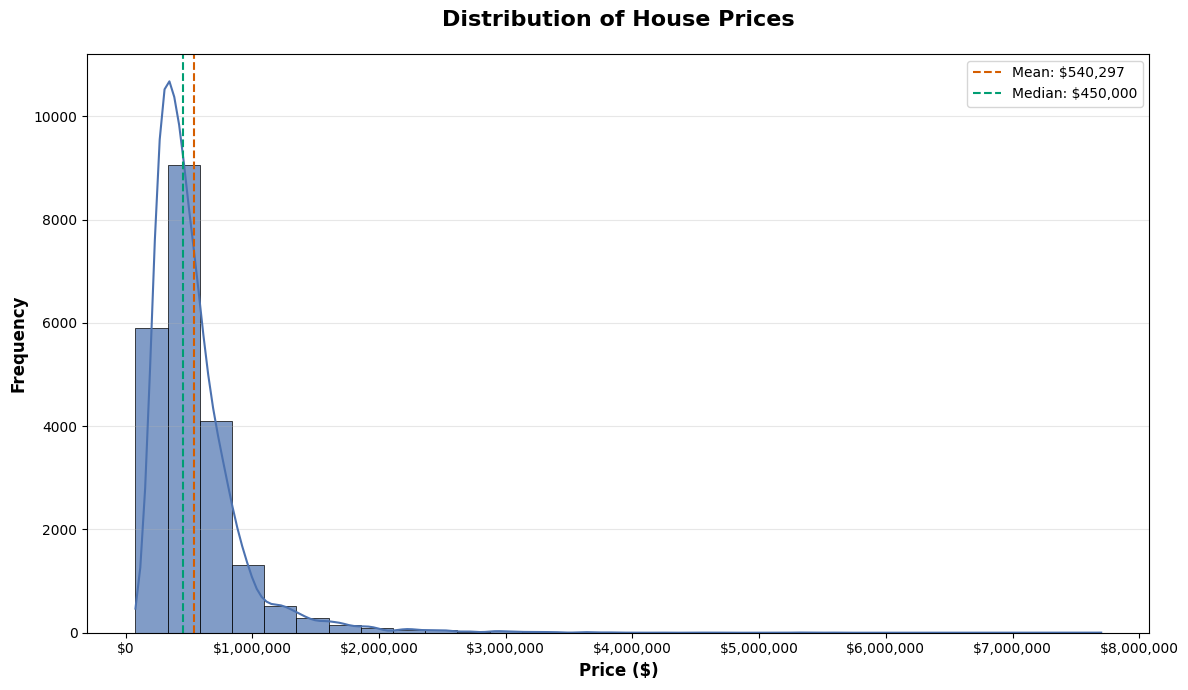

In [10]:
# 3. Univariate Analysis (Distribution of Key Variables)
print("\n## 3. Univariate Analysis")

# Plot the distribution of the target variable 'price'
plt.figure(figsize=(12, 7))

# Use a better bin calculation and add styling
sns.histplot(df_corrected['price'], 
             kde=True, 
             bins=30, 
             color='#4C72B0',  # Blue from colorblind-safe palette, 
             edgecolor='black', alpha=0.7, linewidth=0.5)

plt.title('Distribution of House Prices', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Price ($)', fontsize=12, fontweight='bold')
plt.ylabel('Frequency', fontsize=12, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Format x-axis to show dollar amounts properly
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))

# Add statistical annotations
mean_price = df_corrected['price'].mean()
median_price = df_corrected['price'].median()
plt.axvline(mean_price, color='#D55E00', linestyle='--', linewidth=1.5, 
            label=f'Mean: ${mean_price:,.0f}')
plt.axvline(median_price, color='#009E73', linestyle='--', linewidth=1.5, 
            label=f'Median: ${median_price:,.0f}')

plt.legend()
plt.tight_layout()
plt.show()

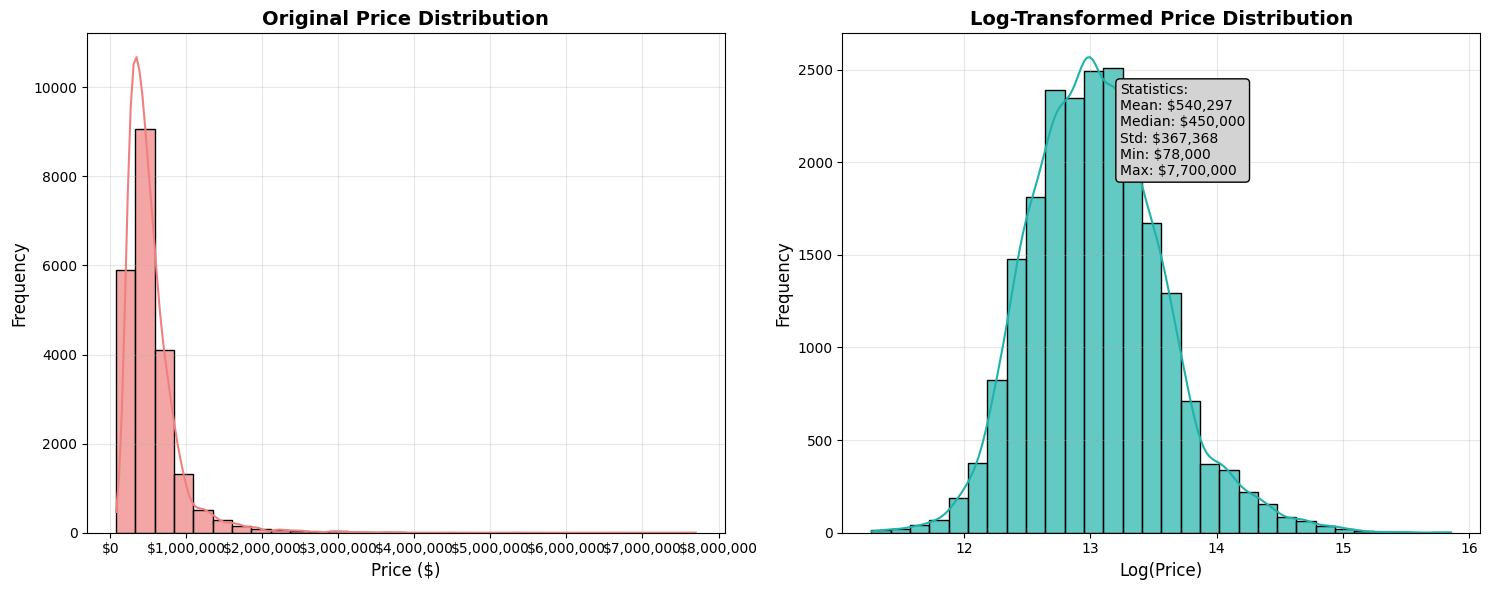

In [11]:
# Plot the distribution of the target variable 'price' with log transformation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Original distribution
sns.histplot(df_corrected['price'], kde=True, bins=30, color='lightcoral', 
             edgecolor='black', alpha=0.7, ax=ax1)
ax1.set_title('Original Price Distribution', fontsize=14, fontweight='bold')
ax1.set_xlabel('Price ($)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x:,.0f}'))
ax1.grid(alpha=0.3)

# Log-transformed distribution
sns.histplot(np.log1p(df_corrected['price']), kde=True, bins=30, color='lightseagreen', 
             edgecolor='black', alpha=0.7, ax=ax2)
ax2.set_title('Log-Transformed Price Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Log(Price)', fontsize=12)
ax2.set_ylabel('Frequency', fontsize=12)
ax2.grid(alpha=0.3)

# Add statistics box
stats_text = f"""Statistics:
Mean: ${df_corrected['price'].mean():,.0f}
Median: ${df_corrected['price'].median():,.0f}
Std: ${df_corrected['price'].std():,.0f}
Min: ${df_corrected['price'].min():,.0f}
Max: ${df_corrected['price'].max():,.0f}"""

fig.text(0.75, 0.70, stats_text, bbox=dict(boxstyle="round,pad=0.3", facecolor="lightgray"), 
         fontsize=10, transform=fig.transFigure)

plt.tight_layout()
plt.show()

=== PRICE CATEGORIES ===
Budget (<$250K): 2297 properties (avg: $205,969)
Affordable ($250K-$400K): 6384 properties (avg: $323,392)
Mid-Range ($400K-$600K): 6552 properties (avg: $489,777)
Premium ($600K-$1M): 4874 properties (avg: $748,011)
Luxury (>$1M): 1490 properties (avg: $1,527,732)

Overall average price: $540,297
Median price: $450,000


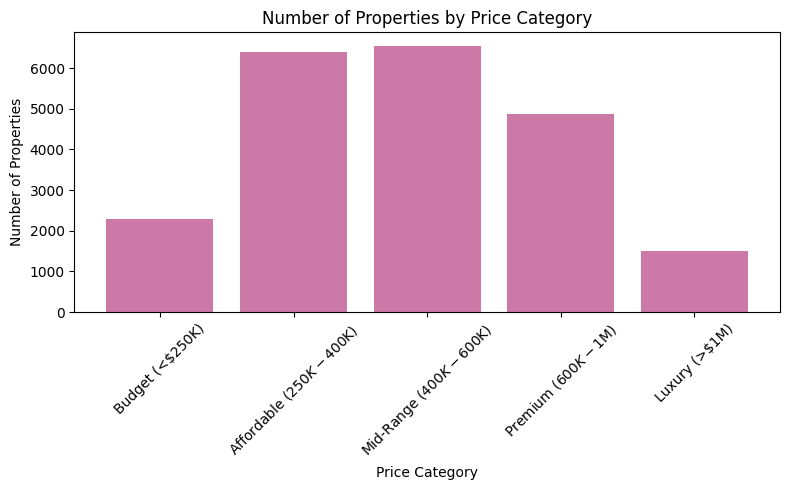

In [12]:
# === Price categories ===
print("=== PRICE CATEGORIES ===")

price_bins = [0, 250000, 400000, 600000, 1000000, float('inf')]
price_labels = [
    'Budget (<$250K)',
    'Affordable ($250K-$400K)',
    'Mid-Range ($400K-$600K)',
    'Premium ($600K-$1M)',
    'Luxury (>$1M)'
]

df_corrected['price_category'] = pd.cut(df_corrected['price'], 
                                        bins=price_bins, labels=price_labels, right=False)
price_summary = df_corrected['price_category'].value_counts().sort_index()

# Print the counts and average prices for each category
for category, count in price_summary.items():
    avg_price = df_corrected[df_corrected['price_category'] == category]['price'].mean()
    print(f"{category}: {count} properties (avg: ${avg_price:,.0f})")

# Print overall statistics
print(f"\nOverall average price: ${df_corrected['price'].mean():,.0f}")
print(f"Median price: ${df_corrected['price'].median():,.0f}")

# === Plotting ===

# Create a bar chart for price categories
plt.figure(figsize=(8,5))  # Set figure size
plt.bar(price_summary.index, price_summary.values, color='#CC79A7'
        )
plt.title('Number of Properties by Price Category')  # Chart title
plt.xlabel('Price Category',loc='center')  # X-axis label
plt.ylabel('Number of Properties')  # Y-axis label
plt.xticks(rotation=45)  # Rotate x-axis labels for readability
plt.tight_layout()  # Adjust layout so labels fit nicely
plt.show()


In [13]:
# === Grade categories ===
print("=== GRADE CATEGORIES ===")

# Grade interpretation (typical scale):
# 6-7: Average, 8: Good, 9: Better, 10: Very Good, 11: Excellent, 12-13: Luxury
grade_bins = [0, 6, 7, 8, 9, 10, float('inf')]
grade_labels = ['Below Average (1-6)', 'Average (7)', 'Good (8)', 'Very Good (9)', 
                'Excellent (10)', 'Luxury (11+)']

df_corrected['grade_category'] = pd.cut(df_corrected['grade'], bins=grade_bins, labels=grade_labels, right=False)
grade_summary = df_corrected['grade_category'].value_counts().sort_index()

for category, count in grade_summary.items():
    avg_grade = df_corrected[df_corrected['grade_category'] == category]['grade'].mean()
    avg_price = df_corrected[df_corrected['grade_category'] == category]['price'].mean()
    print(f"{category}: {count} properties (avg grade: {avg_grade:.1f}, avg price: ${avg_price:,.0f})")


=== GRADE CATEGORIES ===
Below Average (1-6): 270 properties (avg grade: 4.9, avg price: $244,922)
Average (7): 2038 properties (avg grade: 6.0, avg price: $301,917)
Good (8): 8974 properties (avg grade: 7.0, avg price: $402,595)
Very Good (9): 6065 properties (avg grade: 8.0, avg price: $542,987)
Excellent (10): 2615 properties (avg grade: 9.0, avg price: $773,738)
Luxury (11+): 1635 properties (avg grade: 10.4, avg price: $1,258,670)


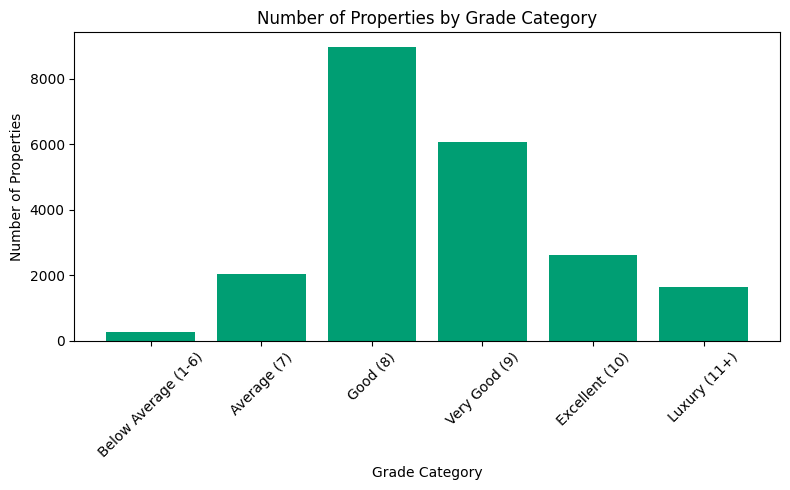

In [14]:
# === Plotting ===
plt.figure(figsize=(8,5))
plt.bar(grade_summary.index, grade_summary.values, color='#009E73')
plt.title('Number of Properties by Grade Category')
plt.xlabel('Grade Category')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.tight_layout()
plt.show()

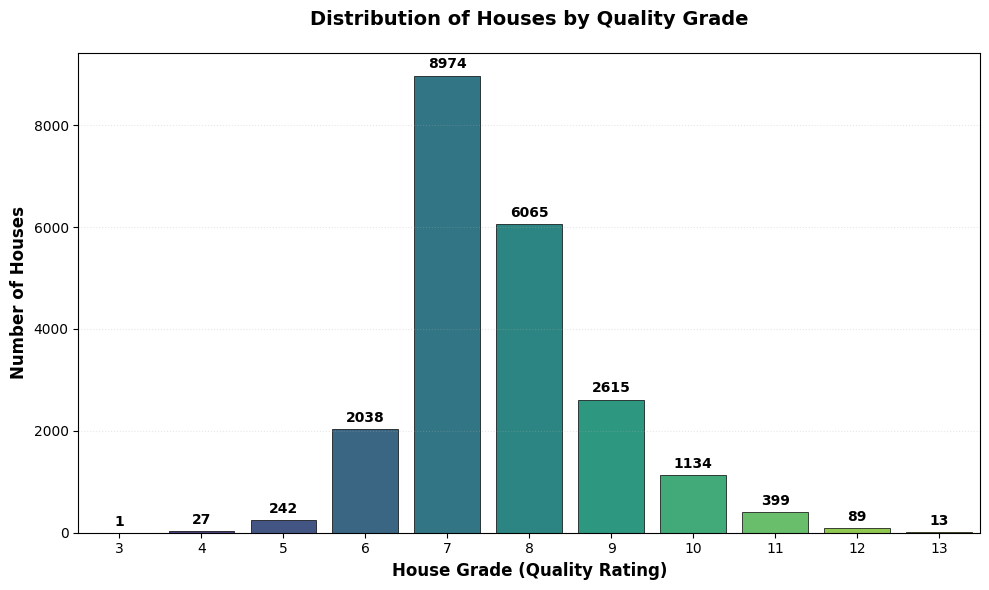

In [15]:
# Plot the count of houses by 'grade' (a measure of quality).
plt.figure(figsize=(10, 6))

# Use colorblind-friendly palette and add patterns
ax = sns.countplot(x='grade', data=df_corrected, palette='viridis', 
                   saturation=0.8, edgecolor='black', linewidth=0.5)

plt.title('Distribution of Houses by Quality Grade', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('House Grade (Quality Rating)', fontsize=12, fontweight='bold')
plt.ylabel('Number of Houses', fontsize=12, fontweight='bold')

# Add value labels on top of each bar
for container in ax.containers:
    ax.bar_label(container, fontsize=10, fontweight='bold', color='black', padding=3)

# Improve grid for better readability
plt.grid(axis='y', alpha=0.3, linestyle=':')

# Use colorblind-friendly color palette
sns.set_palette("colorblind")

plt.tight_layout()
plt.show()

In [16]:
# BEDROOM CATEGORIES
print("\n=== BEDROOM CATEGORIES ===")
bedroom_bins = [0, 2, 3, 4, float('inf')]
bedroom_labels = ['Small (1-2)', 'Medium (3)', 'Large (4)', 'Extra Large (5+)']

df_corrected['bedroom_category'] = pd.cut(df_corrected['bedrooms'], bins=bedroom_bins, labels=bedroom_labels, right=False)
bedroom_summary = df_corrected['bedroom_category'].value_counts().sort_index()

for category, count in bedroom_summary.items():
    avg_bedrooms = df_corrected[df_corrected['bedroom_category'] == category]['bedrooms'].mean()
    avg_price = df_corrected[df_corrected['bedroom_category'] == category]['price'].mean()
    print(f"{category}: {count} properties (avg bedrooms: {avg_bedrooms:.1f}, avg price: ${avg_price:,.0f})")



=== BEDROOM CATEGORIES ===
Small (1-2): 196 properties (avg bedrooms: 1.0, avg price: $318,239)
Medium (3): 2760 properties (avg bedrooms: 2.0, avg price: $401,388)
Large (4): 9824 properties (avg bedrooms: 3.0, avg price: $466,277)
Extra Large (5+): 8817 properties (avg bedrooms: 4.3, avg price: $671,190)


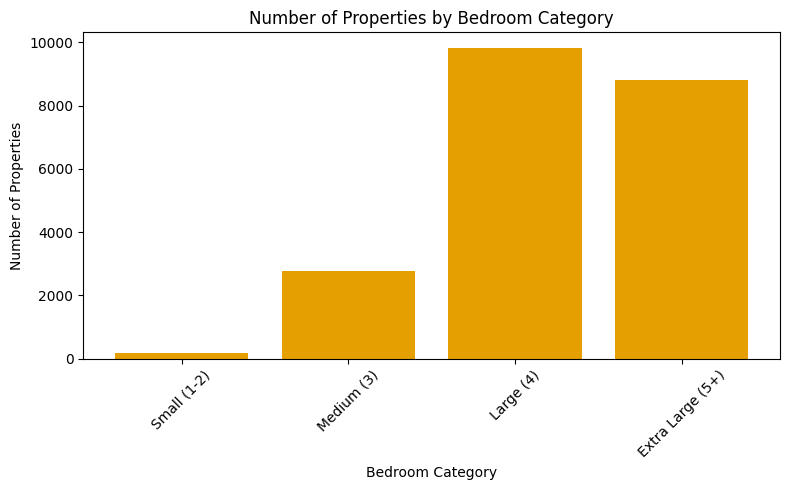

In [17]:
# === Plotting ===
plt.figure(figsize=(8,5))
plt.bar(bedroom_summary.index, bedroom_summary.values, color='#E69F00')
plt.title('Number of Properties by Bedroom Category')
plt.xlabel('Bedroom Category')
plt.ylabel('Number of Properties')
plt.xticks(rotation=45)  # Rotate labels for readability
plt.tight_layout()
plt.show()

In [18]:
# DETAILED STATISTICS
print("\n=== DETAILED STATISTICS ===")
print("\nPrice Statistics:")
print(f"Minimum: ${df_corrected['price'].min():,.0f}")
print(f"25th percentile: ${df_corrected['price'].quantile(0.25):,.0f}")
print(f"Median: ${df_corrected['price'].median():,.0f}")
print(f"75th percentile: ${df_corrected['price'].quantile(0.75):,.0f}")
print(f"Maximum: ${df_corrected['price'].max():,.0f}")

print("\nGrade Statistics:")
grade_counts = df_corrected['grade'].value_counts().sort_index()
for grade, count in grade_counts.items():
    print(f"Grade {grade}: {count} properties")

print("\nBedroom Statistics:")
bedroom_counts = df_corrected['bedrooms'].value_counts().sort_index()
for beds, count in bedroom_counts.items():
    print(f"{beds} bedrooms: {count} properties")



=== DETAILED STATISTICS ===

Price Statistics:
Minimum: $78,000
25th percentile: $322,000
Median: $450,000
75th percentile: $645,000
Maximum: $7,700,000

Grade Statistics:
Grade 3: 1 properties
Grade 4: 27 properties
Grade 5: 242 properties
Grade 6: 2038 properties
Grade 7: 8974 properties
Grade 8: 6065 properties
Grade 9: 2615 properties
Grade 10: 1134 properties
Grade 11: 399 properties
Grade 12: 89 properties
Grade 13: 13 properties

Bedroom Statistics:
1.0 bedrooms: 196 properties
2.0 bedrooms: 2760 properties
3.0 bedrooms: 9824 properties
4.0 bedrooms: 6882 properties
5.0 bedrooms: 1601 properties
6.0 bedrooms: 272 properties
7.0 bedrooms: 38 properties
8.0 bedrooms: 13 properties
9.0 bedrooms: 6 properties
10.0 bedrooms: 3 properties
11.0 bedrooms: 1 properties
33.0 bedrooms: 1 properties


### Cross Analysis


=== CROSS CATEGORY ANALYSIS ===

Price vs Bedroom Categories:
price_category    Budget (<$250K)  Affordable ($250K-$400K)  \
bedroom_category                                              
Small (1-2)                    62                        90   
Medium (3)                    565                       966   
Large (4)                    1326                      3316   
Extra Large (5+)              344                      2012   

price_category    Mid-Range ($400K-$600K)  Premium ($600K-$1M)  Luxury (>$1M)  
bedroom_category                                                               
Small (1-2)                            35                    8              1  
Medium (3)                            913                  282             34  
Large (4)                            3158                 1708            316  
Extra Large (5+)                     2446                 2876           1139  


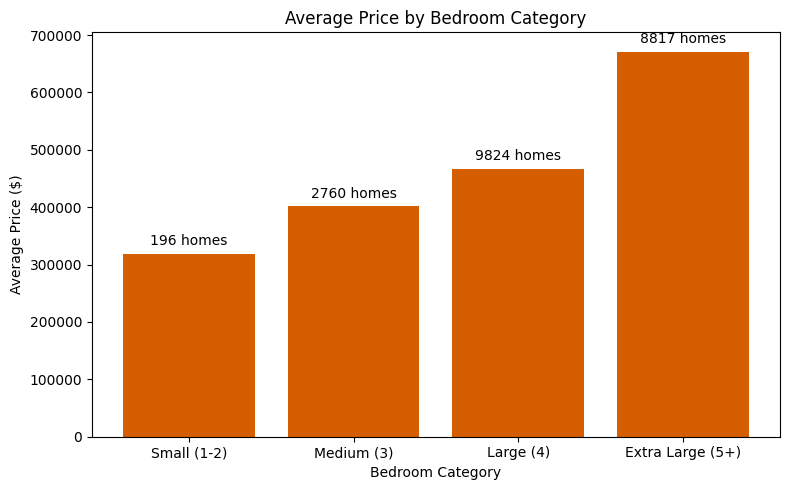

In [19]:
#CROSS ANALYSIS
print("\n=== CROSS CATEGORY ANALYSIS ===")
print("\nPrice vs Bedroom Categories:")

cross_tab = pd.crosstab(df_corrected['bedroom_category'], df_corrected['price_category'])
print(cross_tab)

# Calculate the average price for each bedroom category
avg_price_per_bedroom = df_corrected.groupby('bedroom_category')['price'].mean()

# Count of properties for reference (optional for labeling)
count_per_bedroom = df_corrected['bedroom_category'].value_counts().sort_index()

plt.figure(figsize=(8,5))

# Bar chart for average price
bars = plt.bar(
    avg_price_per_bedroom.index,
    avg_price_per_bedroom.values,
    color='#D55E00'
)

# Add the number of properties on top of each bar
for bar, count in zip(bars, count_per_bedroom):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 10000, f"{count} homes",
             ha='center', va='bottom', fontsize=10)

plt.title('Average Price by Bedroom Category')
plt.xlabel('Bedroom Category')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


Price vs Grade Categories:
price_category       Budget (<$250K)  Affordable ($250K-$400K)  \
grade_category                                                   
Below Average (1-6)              162                        86   
Average (7)                      804                       859   
Good (8)                        1219                      3757   
Very Good (9)                    111                      1518   
Excellent (10)                     1                       159   
Luxury (11+)                       0                         5   

price_category       Mid-Range ($400K-$600K)  Premium ($600K-$1M)  \
grade_category                                                      
Below Average (1-6)                       18                    4   
Average (7)                              329                   41   
Good (8)                                3013                  958   
Very Good (9)                           2525                 1709   
Excellent (10)               

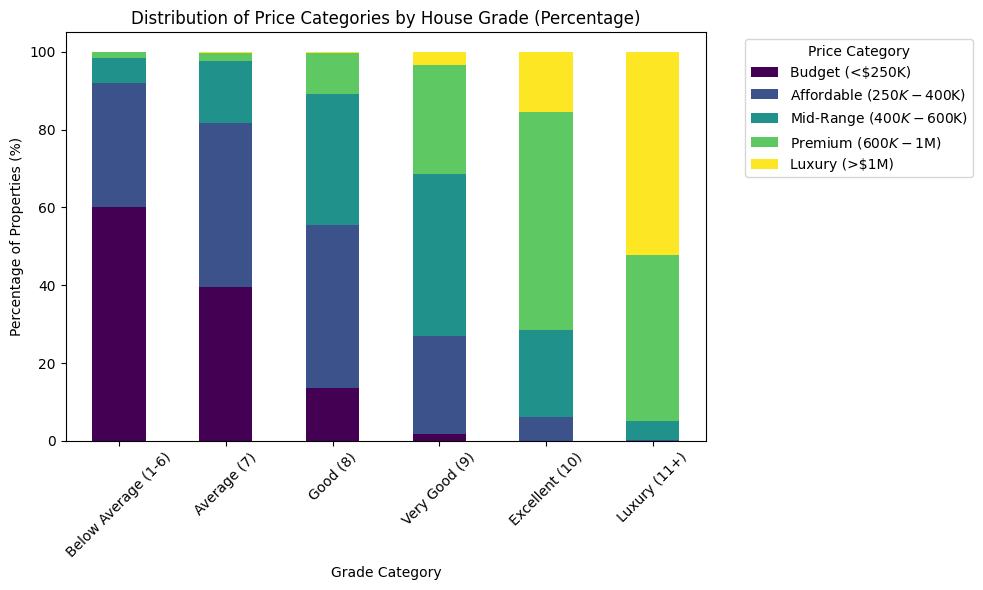

In [20]:
print("\nPrice vs Grade Categories:")
cross_tab2 = pd.crosstab(df_corrected['grade_category'], df_corrected['price_category'])
print(cross_tab2)

# Create the cross-tab
cross_tab2 = pd.crosstab(df_corrected['grade_category'], df_corrected['price_category'])

# Optionally, normalize to percentages for easier comparison
cross_tab2_norm = cross_tab2.div(cross_tab2.sum(axis=1), axis=0) * 100

# Plot a stacked bar chart
cross_tab2_norm.plot(
    kind='bar',
    stacked=True,
    figsize=(10,6),
    colormap='viridis'
)

plt.title('Distribution of Price Categories by House Grade (Percentage)')
plt.xlabel('Grade Category')
plt.ylabel('Percentage of Properties (%)')
plt.xticks(rotation=45)
plt.legend(title='Price Category', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


<Figure size 1400x1200 with 0 Axes>

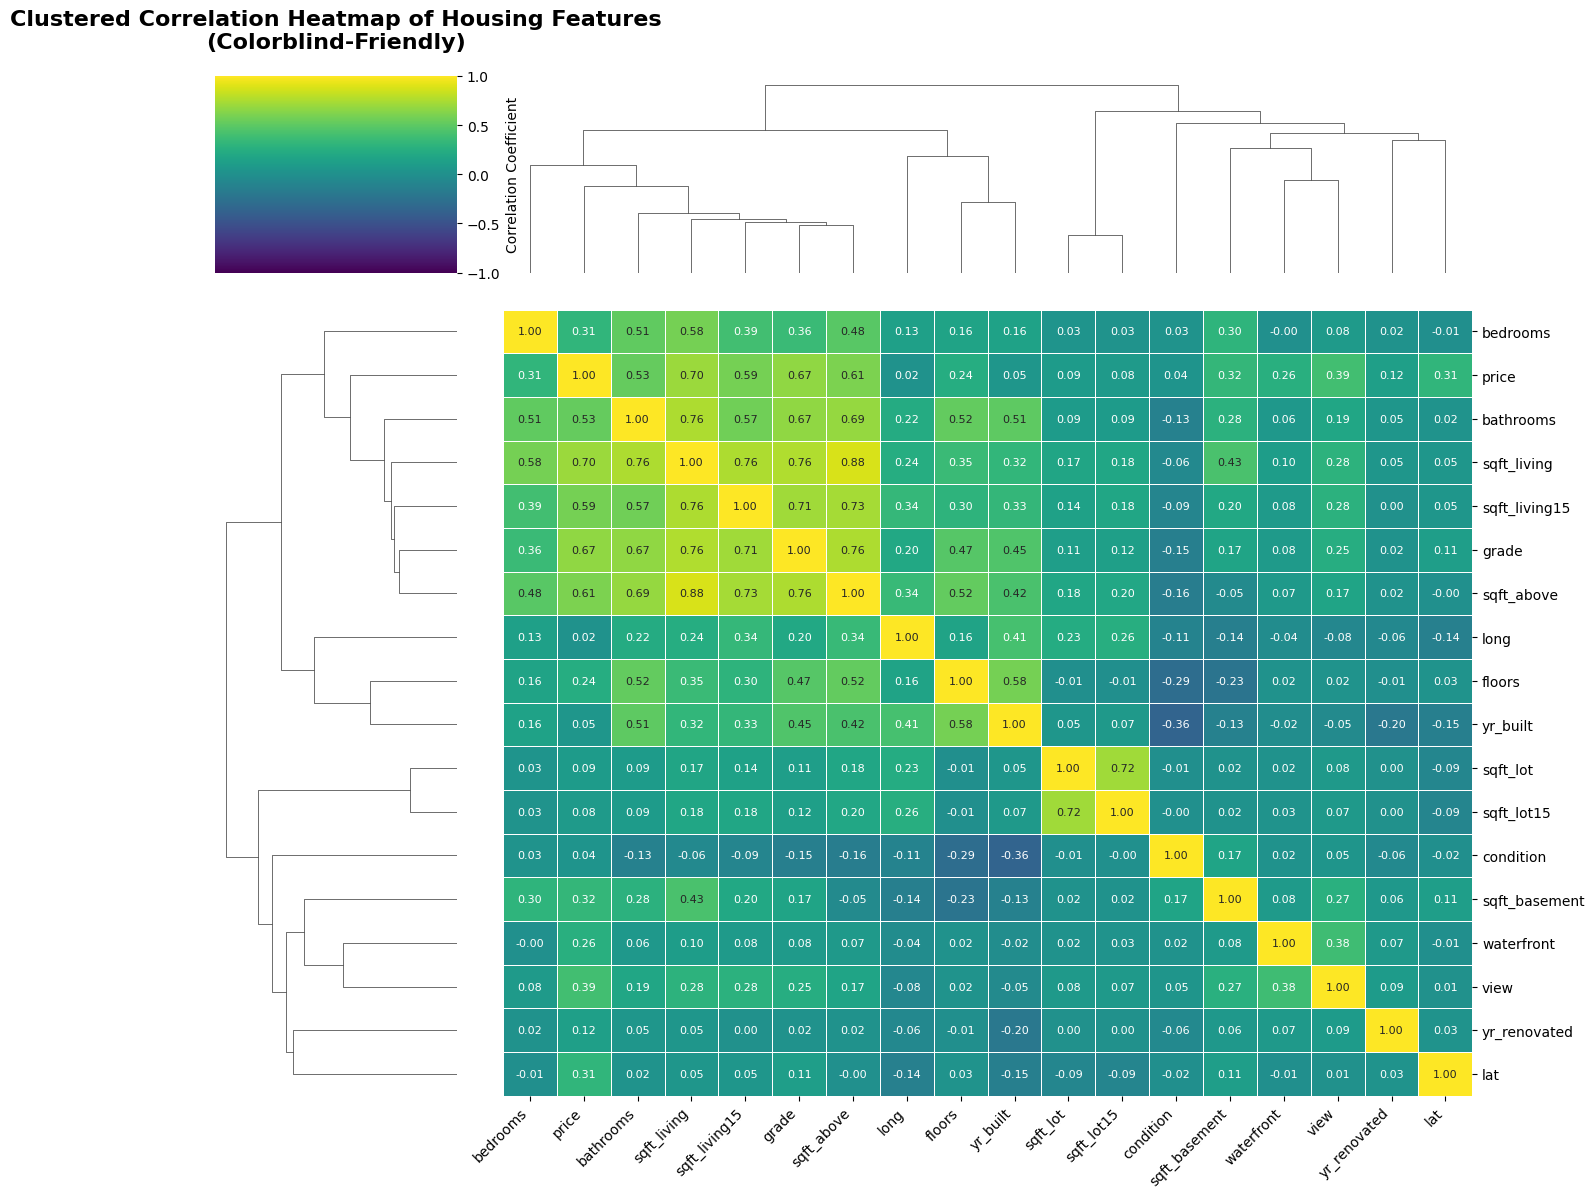

Feature Correlation Insights:

Strongest Positive Correlations:
sqft_above   sqft_living     0.876
sqft_living  sqft_above      0.876
             grade           0.763
grade        sqft_living     0.763
sqft_living  sqft_living15   0.756
dtype: float64

Strongest Negative Correlations:
condition      yr_built    -0.362
yr_built       condition   -0.362
condition      floors      -0.293
floors         condition   -0.293
sqft_basement  floors      -0.232
dtype: float64


In [21]:
# Calculate correlation matrix
corr_matrix = df_corrected[numerical_cols].corr()

# Create clustered heatmap with colorblind-friendly colors
plt.figure(figsize=(14, 12))

# Create clustered heatmap using seaborn's clustermap
# - Centers the color scale at 0 to highlight positive vs. negative correlations
# - Displays correlation values inside each cell (formatted to 2 decimals)
# - Adds thin white grid lines for readability
# - Fixes the color scale between -1 and 1 (valid correlation range)
# - Includes a labeled colorbar
# - Produces a larger figure size for better visibility

g = sns.clustermap(corr_matrix, 
                   cmap='viridis',  # Colorblind-friendly
                   center=0,
                   annot=True,  # Show correlation values
                   fmt='.2f',   # Format to 2 decimal places
                   annot_kws={'size': 8},
                   linewidths=0.5,
                   linecolor='white',
                   cbar_kws={'label': 'Correlation Coefficient'},
                   vmin=-1, vmax=1,  # Fixed scale for correlations
                   figsize=(14, 12))
# Improve readability
plt.title('Clustered Correlation Heatmap of Housing Features\n(Colorblind-Friendly)', 
          fontsize=16, fontweight='bold', pad=20)

# Rotate x-axis labels for better readability
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), 
                            rotation=45, 
                            horizontalalignment='right')

# Adjust layout
plt.tight_layout()
plt.show()

# Print some insights
print("Feature Correlation Insights:")
print("=" * 50)

# Identify strong positive correlations:
# - Convert the correlation matrix into a Series using unstack(), then sort values in descending order
# - Remove self-correlations (which are always 1.0) by filtering out values ≥ 0.999
strong_pos_corr = corr_matrix.unstack().sort_values(ascending=False)
strong_pos_corr = strong_pos_corr[strong_pos_corr < 0.999]

print("\nStrongest Positive Correlations:")
print(strong_pos_corr.head(5))

print("\nStrongest Negative Correlations:")
strong_neg_corr = corr_matrix.unstack().sort_values()
print(strong_neg_corr.head(5))

## Locating the houses geographically

In [ ]:
# Define Seattle city zipcodes 
# Seattle (981xx) and suburban (980xx) zipcodes

# df['zipcode'].unique()
## Extracts the zipcode column from df.
## .unique() returns a NumPy array of all unique zipcodes in the dataset.
seattle_zipcodes = {z for z in df_corrected['zipcode'].unique() if 98100 <= z <= 98199}
suburban_zipcodes = {z for z in df_corrected['zipcode'].unique() if 98000 <= z <= 98099}

# Step 3: Classify each house as "In City" or "Outside City"
print("\n Step 3: Classifying houses...")

def where_is_house(zipcode):
    """Simple function to check if a house is in Seattle or outside"""
    if zipcode in seattle_zipcodes:
        return "In Seattle City"
    else:
        return "Outside Seattle"
    
# Make a new dataframe so the original df_bedroom is NOT changed
df_loc = df_corrected.copy()

# Add the new 'location' column to the NEW dataframe
df_loc['location'] = df_loc['zipcode'].apply(where_is_house)

# Apply the classification to each row
df_loc['location'] = df_loc['zipcode'].apply(where_is_house)

# Count how many houses in each category
location_counts = df_loc['location'].value_counts()
print("House locations:")
for location, count in location_counts.items():
    print(f"  {location}: {count} houses")



🏷️ Step 3: Classifying houses...
House locations:
  Outside Seattle: 12624 houses
  In Seattle City: 8973 houses


In [23]:
print(df_loc.head(2))

        date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0 2014-10-13 221900.000     3.000      1.000     1180.000  5650.000       1   
1 2014-12-09 538000.000     3.000      2.250     2570.000  7242.000       2   

   waterfront  view  condition  ...  yr_renovated  zipcode    lat     long  \
0           0     0          3  ...         0.000    98178 47.511 -122.257   
1           0     0          3  ...     19910.000    98125 47.721 -122.319   

   sqft_living15  sqft_lot15           price_category  grade_category  \
0       1340.000    5650.000          Budget (<$250K)        Good (8)   
1       1690.000    7639.000  Mid-Range ($400K-$600K)        Good (8)   

   bedroom_category         location  
0         Large (4)  In Seattle City  
1         Large (4)  In Seattle City  

[2 rows x 24 columns]


## When are houses mostly sold

In [24]:
print("=== MONTHLY HOUSE SALES ANALYSIS ===\n")

# Extract month and month name from date
df_loc['month'] = df_loc['date'].dt.month
df_loc['month_name'] = df_loc['date'].dt.month_name()
df_loc['year'] = df_loc['date'].dt.year

# Monthly sales count
monthly_sales = df_loc['month_name'].value_counts()

# Reorder months chronologically
month_order = ['January', 'February', 'March', 'April', 'May', 'June', 
              'July', 'August', 'September', 'October', 'November', 'December']
monthly_sales = monthly_sales.reindex(month_order)

print("HOUSE SALES BY MONTH:")
print("=" * 40)

total_sales = len(df_loc)
for month in month_order:
    count = monthly_sales.get(month, 0)
    percentage = (count / total_sales) * 100
    print(f"{month:12}: {count:2} sales ({percentage:5.1f}%)")


# Seasonal analysis
print(f"\n🌤️  SEASONAL ANALYSIS:")
seasons = {
    'Winter (Dec-Feb)': [12, 1, 2],
    'Spring (Mar-May)': [3, 4, 5],
    'Summer (Jun-Aug)': [6, 7, 8],
    'Fall (Sep-Nov)': [9, 10, 11]
}

for season, months in seasons.items():
    season_sales = len(df_loc[df_loc['month'].isin(months)])
    percentage = (season_sales / total_sales) * 100
    print(f"{season:15}: {season_sales:2} sales ({percentage:5.1f}%) - Avg price: ${avg_price:,.0f}")


# Find the busiest month
busiest_month = monthly_sales.idxmax()
busiest_count = monthly_sales.max()
busiest_percentage = (busiest_count / total_sales) * 100

=== MONTHLY HOUSE SALES ANALYSIS ===

HOUSE SALES BY MONTH:
January     : 978 sales (  4.5%)
February    : 1247 sales (  5.8%)
March       : 1875 sales (  8.7%)
April       : 2229 sales ( 10.3%)
May         : 2414 sales ( 11.2%)
June        : 2178 sales ( 10.1%)
July        : 2211 sales ( 10.2%)
August      : 1939 sales (  9.0%)
September   : 1771 sales (  8.2%)
October     : 1876 sales (  8.7%)
November    : 1409 sales (  6.5%)
December    : 1470 sales (  6.8%)

🌤️  SEASONAL ANALYSIS:
Winter (Dec-Feb): 3695 sales ( 17.1%) - Avg price: $671,190
Spring (Mar-May): 6518 sales ( 30.2%) - Avg price: $671,190
Summer (Jun-Aug): 6328 sales ( 29.3%) - Avg price: $671,190
Fall (Sep-Nov) : 5056 sales ( 23.4%) - Avg price: $671,190


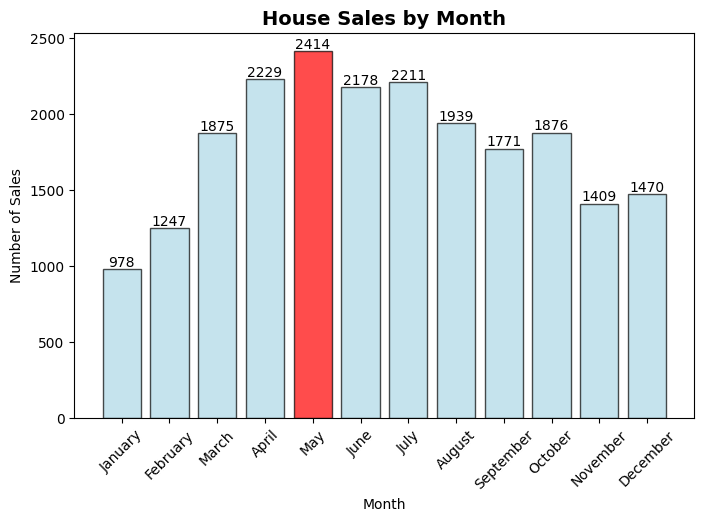

In [25]:
# Plot 1: Monthly sales bar chart
colors = ['lightblue' if month != busiest_month else 'red' for month in month_order]
bars = plt.bar(month_order, [monthly_sales.get(month, 0) for month in month_order], 
               color=colors, alpha=0.7, edgecolor='black')
plt.title('House Sales by Month', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Sales')
plt.xticks(rotation=45)
# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    if height > 0:
        plt.text(bar.get_x() + bar.get_width()/2., height,
                f'{int(height)}', ha='center', va='bottom')

Text(0.5, 1.0, 'Sales by Season')

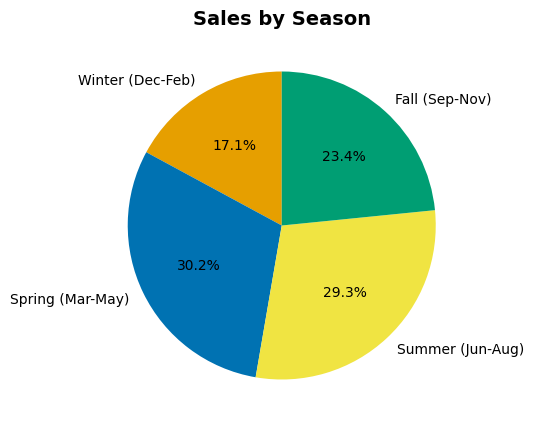

In [26]:
# Plot 2: Seasonal sales pie chart
seasonal_counts = [len(df_loc[df_loc['month'].isin(months)]) for season, months in seasons.items()]
colors = ['#E69F00', '#0072B2', '#F0E442', '#009E73']
plt.pie(seasonal_counts, labels=seasons.keys(), autopct='%1.1f%%', colors=colors, startangle=90)
plt.title('Sales by Season', fontsize=14, fontweight='bold')

# 2. Hypothesis testing

In [27]:
print(df_loc.head(2))

        date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
0 2014-10-13 221900.000     3.000      1.000     1180.000  5650.000       1   
1 2014-12-09 538000.000     3.000      2.250     2570.000  7242.000       2   

   waterfront  view  condition  ...     long  sqft_living15  sqft_lot15  \
0           0     0          3  ... -122.257       1340.000    5650.000   
1           0     0          3  ... -122.319       1690.000    7639.000   

            price_category  grade_category  bedroom_category         location  \
0          Budget (<$250K)        Good (8)         Large (4)  In Seattle City   
1  Mid-Range ($400K-$600K)        Good (8)         Large (4)  In Seattle City   

   month  month_name  year  
0     10     October  2014  
1     12    December  2014  

[2 rows x 27 columns]


In [28]:
# Hypothesis 1: City houses cost > Suburb houses cost
print("🏙️ ANALYZING CITY vs SUBURB HOUSE PRICES")
print("=" * 50)

print("📍 LOCATION CLASSIFICATION RESULTS:")
print(f"Seattle City zipcodes: {len(seattle_zipcodes)}")
print(f"Suburban zipcodes: {len(suburban_zipcodes)}")
print(f"Seattle City houses: {len(df_loc[df_loc['location'] == 'In Seattle City'])}")
print(f"Outside Seattle houses: {len(df_loc[df_loc['location'] == 'Outside Seattle'])}")

# Step 1: Separate the data
city_houses = df_loc[df_loc['location'] == 'In Seattle City']
suburb_houses = df_loc[df_loc['location'] == 'Outside Seattle']

# Step 2: Basic price comparison
print(f"\n💰 PRICE COMPARISON:")
city_avg_price = city_houses['price'].mean()
suburb_avg_price = suburb_houses['price'].mean()
price_difference = city_avg_price - suburb_avg_price
price_ratio = city_avg_price / suburb_avg_price

print(f"Seattle City average price: ${city_avg_price:,.0f}")
print(f"Outside Seattle average price: ${suburb_avg_price:,.0f}")
print(f"Price difference: ${price_difference:,.0f}")

if price_difference > 0:
    print(f"✅ Seattle City houses are ${price_difference:,.0f} MORE expensive")
    print(f"   That's {price_ratio:.2f}x the price of Outside Seattle houses")
else:
    print(f"✅ Outside Seattle houses are ${abs(price_difference):,.0f} MORE expensive")
    print(f"   Seattle City houses are {1/price_ratio:.2f}x cheaper")

# Step 3: Statistical significance test
print(f"\n📈 STATISTICAL SIGNIFICANCE:")
t_stat, p_value = stats.ttest_ind(city_houses['price'], suburb_houses['price'], equal_var=False)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_value:.6f}")

if p_value < 0.05:
    print("✅ The price difference is STATISTICALLY SIGNIFICANT (p < 0.05)")
    if price_difference > 0:
        print("   Seattle City houses are SIGNIFICANTLY more expensive")
    else:
        print("   Outside Seattle houses are SIGNIFICANTLY more expensive")
else:
    print("❌ The price difference is NOT statistically significant")
    print("   There's no strong evidence that one area is more expensive than the other")


🏙️ ANALYZING CITY vs SUBURB HOUSE PRICES
📍 LOCATION CLASSIFICATION RESULTS:
Seattle City zipcodes: 29
Suburban zipcodes: 41
Seattle City houses: 8973
Outside Seattle houses: 12624

💰 PRICE COMPARISON:
Seattle City average price: $535,086
Outside Seattle average price: $544,000
Price difference: $-8,915
✅ Outside Seattle houses are $8,915 MORE expensive
   Seattle City houses are 1.02x cheaper

📈 STATISTICAL SIGNIFICANCE:
T-statistic: -1.79
P-value: 0.072757
❌ The price difference is NOT statistically significant
   There's no strong evidence that one area is more expensive than the other


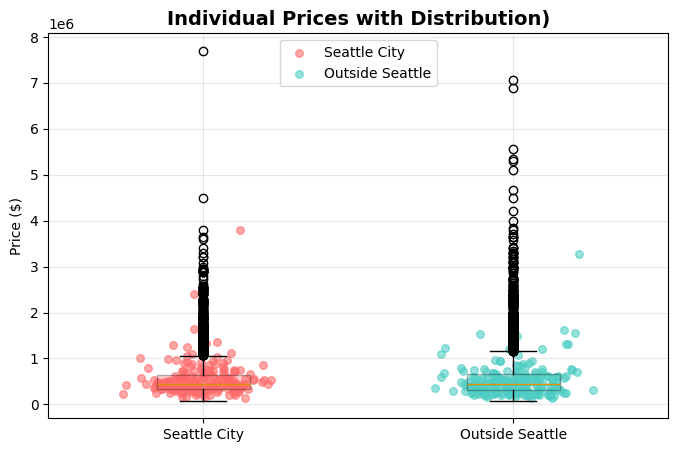

In [30]:
# Sample for better visualization (swarm plots can be slow with large data)
city_sample = city_houses.sample(min(200, len(city_houses)))
suburb_sample = suburb_houses.sample(min(200, len(suburb_houses)))

# Create positions for swarm plot
city_positions = np.random.normal(1, 0.1, len(city_sample))
suburb_positions = np.random.normal(2, 0.1, len(suburb_sample))

plt.scatter(city_positions, city_sample['price'], alpha=0.6, color='#FF6B6B', s=30, label='Seattle City')
plt.scatter(suburb_positions, suburb_sample['price'], alpha=0.6, color='#4ECDC4', s=30, label='Outside Seattle')

# Add box plots
box_data = [city_houses['price'], suburb_houses['price']]
box_parts = plt.boxplot(box_data, positions=[1, 2], widths=0.3, patch_artist=True)

# Color the boxes
colors = ['#FF6B6B', '#4ECDC4']
for patch, color in zip(box_parts['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.3)

plt.xticks([1, 2], ['Seattle City', 'Outside Seattle'])
plt.title('Individual Prices with Distribution)', fontsize=14, fontweight='bold')
plt.ylabel('Price ($)')
#plt.legend(loc='upper right') 
plt.legend(loc='best') 
plt.grid(True, alpha=0.3)

In [31]:
# Hypothesis 2: Bigger the house, more expensive it is

print(" ANALYZING CORRELATION: HOUSE SIZE vs PRICE")
print("=" * 50)

# Step 1: Basic correlation calculation
correlation = df_loc['sqft_living'].corr(df_loc['price'])
print(f"📊 CORRELATION COEFFICIENT: {correlation:.3f}")

# Interpret the correlation
if abs(correlation) >= 0.7:
    strength = "STRONG"
elif abs(correlation) >= 0.5:
    strength = "MODERATE"
elif abs(correlation) >= 0.3:
    strength = "WEAK"
else:
    strength = "VERY WEAK"

direction = "positive" if correlation > 0 else "negative"
print(f"💡 INTERPRETATION: {strength} {direction} correlation")

# Step 2: Statistical significance
r_value, p_value = stats.pearsonr(df_loc['sqft_living'], df_loc['price'])
print(f"📈 STATISTICAL SIGNIFICANCE:")
print(f"   R-value: {r_value:.3f}")
print(f"   P-value: {p_value:.6f}")
print(f"   The correlation is {'STATISTICALLY SIGNIFICANT' if p_value < 0.05 else 'NOT statistically significant'}")

 ANALYZING CORRELATION: HOUSE SIZE vs PRICE
📊 CORRELATION COEFFICIENT: 0.702
💡 INTERPRETATION: STRONG positive correlation
📈 STATISTICAL SIGNIFICANCE:
   R-value: 0.702
   P-value: 0.000000
   The correlation is STATISTICALLY SIGNIFICANT



 CREATING CORRELATION VISUALIZATIONS...


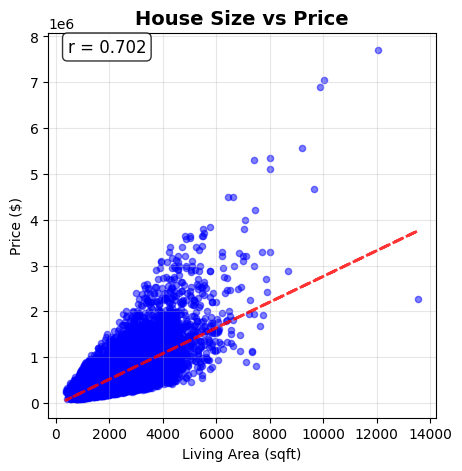

In [33]:
# Step 3: Create comprehensive visualizations
print(f"\n CREATING CORRELATION VISUALIZATIONS...")

plt.figure(figsize=(5, 5))

# Plot 1: Scatter plot with regression line
plt.scatter(df_loc['sqft_living'], df_loc['price'], alpha=0.5, s=20, color='blue')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.title(f'House Size vs Price', fontsize=14, fontweight='bold')

# Add regression line
z = np.polyfit(df_loc['sqft_living'], df_loc['price'], 1)
p = np.poly1d(z)
plt.plot(df_loc['sqft_living'], 
         p(df_loc['sqft_living']), "r--", alpha=0.8, linewidth=2)

# Add correlation text
plt.text(0.05, 0.95, f'r = {correlation:.3f}', transform=plt.gca().transAxes, 
         fontsize=12, bbox=dict(boxstyle="round,pad=0.3", facecolor="white", alpha=0.8))
plt.grid(True, alpha=0.3)

 CHECKING IF SEASONAL SALES DIFFERENCES ARE SIGNIFICANT
 SEASONAL SALES DATA:
  Winter: 3695 sales (17.1%)
  Spring: 6518 sales (30.2%)
  Summer: 6328 sales (29.3%)
  Fall: 5056 sales (23.4%)

 BASIC COMPARISON:
Spring has 2,823 more sales than Winter
That's 1.8x more sales in Spring!

 STATISTICAL TEST:
Testing: Are sales equally distributed across seasons?
Chi-square statistic: 951.33
P-value: 0.0000000000

 RESULT:
   YES - The seasonal difference is STATISTICALLY SIGNIFICANT!
   Sales are NOT equally distributed across seasons
   The pattern is real and not due to random chance

 CREATING SIMPLE CHART...


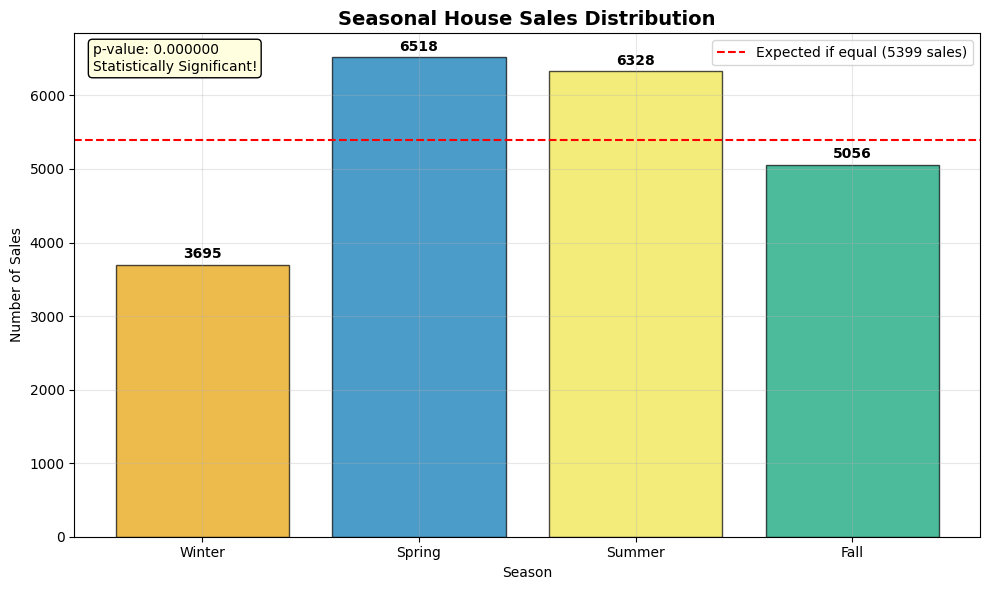


 PRACTICAL SIGNIFICANCE:
Busiest season: Spring (6518 sales)
Slowest season: Winter (3695 sales)
Difference: 2,823 sales
Ratio: 1.8x more sales in Spring
  This is a LARGE practical difference for business planning

SUMMARY:
Statistical significance: YES
Practical importance: 1.8x difference between seasons


In [37]:
# Hypothesis 3: Sales are not season dependent

print(" CHECKING IF SEASONAL SALES DIFFERENCES ARE SIGNIFICANT")
print("=" * 50)

# seasonal sales data ( This is from the output of seasonal analysis)
seasonal_sales = {
    'Winter': 3695,
    'Spring': 6518, 
    'Summer': 6328,
    'Fall': 5056
}

total_sales = sum(seasonal_sales.values())

print(" SEASONAL SALES DATA:")
for season, sales in seasonal_sales.items():
    percentage = (sales / total_sales) * 100
    print(f"  {season}: {sales} sales ({percentage:.1f}%)")

# Step 1: Simple comparison
print(f"\n BASIC COMPARISON:")
print(f"Spring has {6518 - 3695:,} more sales than Winter")
print(f"That's {(6518/3695):.1f}x more sales in Spring!")

# Step 2: Chi-square test for equal distribution
print(f"\n STATISTICAL TEST:")
print("Testing: Are sales equally distributed across seasons?")

# Expected sales if equal distribution
expected_sales = total_sales / 4  # Equal across 4 seasons

# Perform chi-square test
observed = list(seasonal_sales.values())
expected = [expected_sales] * 4  # All seasons should have same sales if equal

chi2, p_value = stats.chisquare(observed, expected)

print(f"Chi-square statistic: {chi2:.2f}")
print(f"P-value: {p_value:.10f}")

# Step 3: Interpretation
print(f"\n RESULT:")
if p_value < 0.05:
    print("   YES - The seasonal difference is STATISTICALLY SIGNIFICANT!")
    print("   Sales are NOT equally distributed across seasons")
    print("   The pattern is real and not due to random chance")
else:
    print("   NO - The seasonal difference is NOT statistically significant")
    print("   Sales might be equally distributed across seasons")
    print("   The pattern could be due to random chance")

# Step 4: Simple visualization
print(f"\n CREATING SIMPLE CHART...")

plt.figure(figsize=(10, 6))

# Bar chart
seasons = list(seasonal_sales.keys())
sales = list(seasonal_sales.values())
colors = ['#E69F00', '#0072B2', '#F0E442', '#009E73']

bars = plt.bar(seasons, sales, color=colors, alpha=0.7, edgecolor='black')

# Add expected line if equal distribution
plt.axhline(y=expected_sales, color='red', linestyle='--', 
           label=f'Expected if equal ({expected_sales:.0f} sales)')

# Add values on bars
for bar, sale in zip(bars, sales):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{sale}', ha='center', va='bottom', fontweight='bold')

plt.title('Seasonal House Sales Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Season')
plt.ylabel('Number of Sales')
plt.legend()
plt.grid(True, alpha=0.3)

# Add statistical result to plot
result_text = "Statistically Significant!" if p_value < 0.05 else "Not Significant"
plt.text(0.02, 0.98, f'p-value: {p_value:.6f}\n{result_text}', 
         transform=plt.gca().transAxes, bbox=dict(boxstyle="round,pad=0.3", 
         facecolor="lightyellow" if p_value < 0.05 else "lightgray"),
         verticalalignment='top')

plt.tight_layout()
plt.show()

# Step 5: Practical significance
print(f"\n PRACTICAL SIGNIFICANCE:")
busiest = max(seasonal_sales, key=seasonal_sales.get)
slowest = min(seasonal_sales, key=seasonal_sales.get)
difference = seasonal_sales[busiest] - seasonal_sales[slowest]
ratio = seasonal_sales[busiest] / seasonal_sales[slowest]

print(f"Busiest season: {busiest} ({seasonal_sales[busiest]} sales)")
print(f"Slowest season: {slowest} ({seasonal_sales[slowest]} sales)")
print(f"Difference: {difference:,} sales")
print(f"Ratio: {ratio:.1f}x more sales in {busiest}")

if ratio > 1.5:
    print("  This is a LARGE practical difference for business planning")
elif ratio > 1.2:
    print("  This is a MODERATE practical difference")
else:
    print("  This is a SMALL practical difference")

print(f"\n" + "=" * 50)
print("SUMMARY:")
print(f"Statistical significance: {'YES' if p_value < 0.05 else 'NO'}")
print(f"Practical importance: {ratio:.1f}x difference between seasons")
print("=" * 50)

# 3. Answering my clients questions

In [42]:
## 1-2 bedroom apartments in grade average or above

print("=== HOUSES WITH 1-2 BEDROOMS AND AVERAGE OR ABOVE GRADE ===\n")

# Step 1: Filter for 1-2 bedrooms
one_two_bedrooms = df_loc[(df_loc['bedrooms'] >= 1) & (df_loc['bedrooms'] <= 2)]
print(f"Found {len(one_two_bedrooms)} houses with 1-2 bedrooms")

# Step 2: Filter for average or above grade (grade 7 or higher)
# In housing data, grade 7 is typically considered "average"
good_houses = one_two_bedrooms[one_two_bedrooms['grade'] >= 7]
print(f"Found {len(good_houses)} houses with 1-2 bedrooms AND grade 7 or above\n")

=== HOUSES WITH 1-2 BEDROOMS AND AVERAGE OR ABOVE GRADE ===

Found 2956 houses with 1-2 bedrooms
Found 1876 houses with 1-2 bedrooms AND grade 7 or above



In [44]:
print("\n=== STATISTICS ===")
print(f"Total matching houses: {len(good_houses)}")
print(f"Average price: ${good_houses['price'].mean():,.0f}")
print(f"Minimum price: ${good_houses['price'].min():,.0f}")
print(f"Maximum price: ${good_houses['price'].max():,.0f}")
print(f"Average living area: {good_houses['sqft_living'].mean():.0f} sqft")


=== STATISTICS ===
Total matching houses: 1876
Average price: $456,119
Minimum price: $90,000
Maximum price: $3,280,000
Average living area: 1372 sqft



Creating plots...


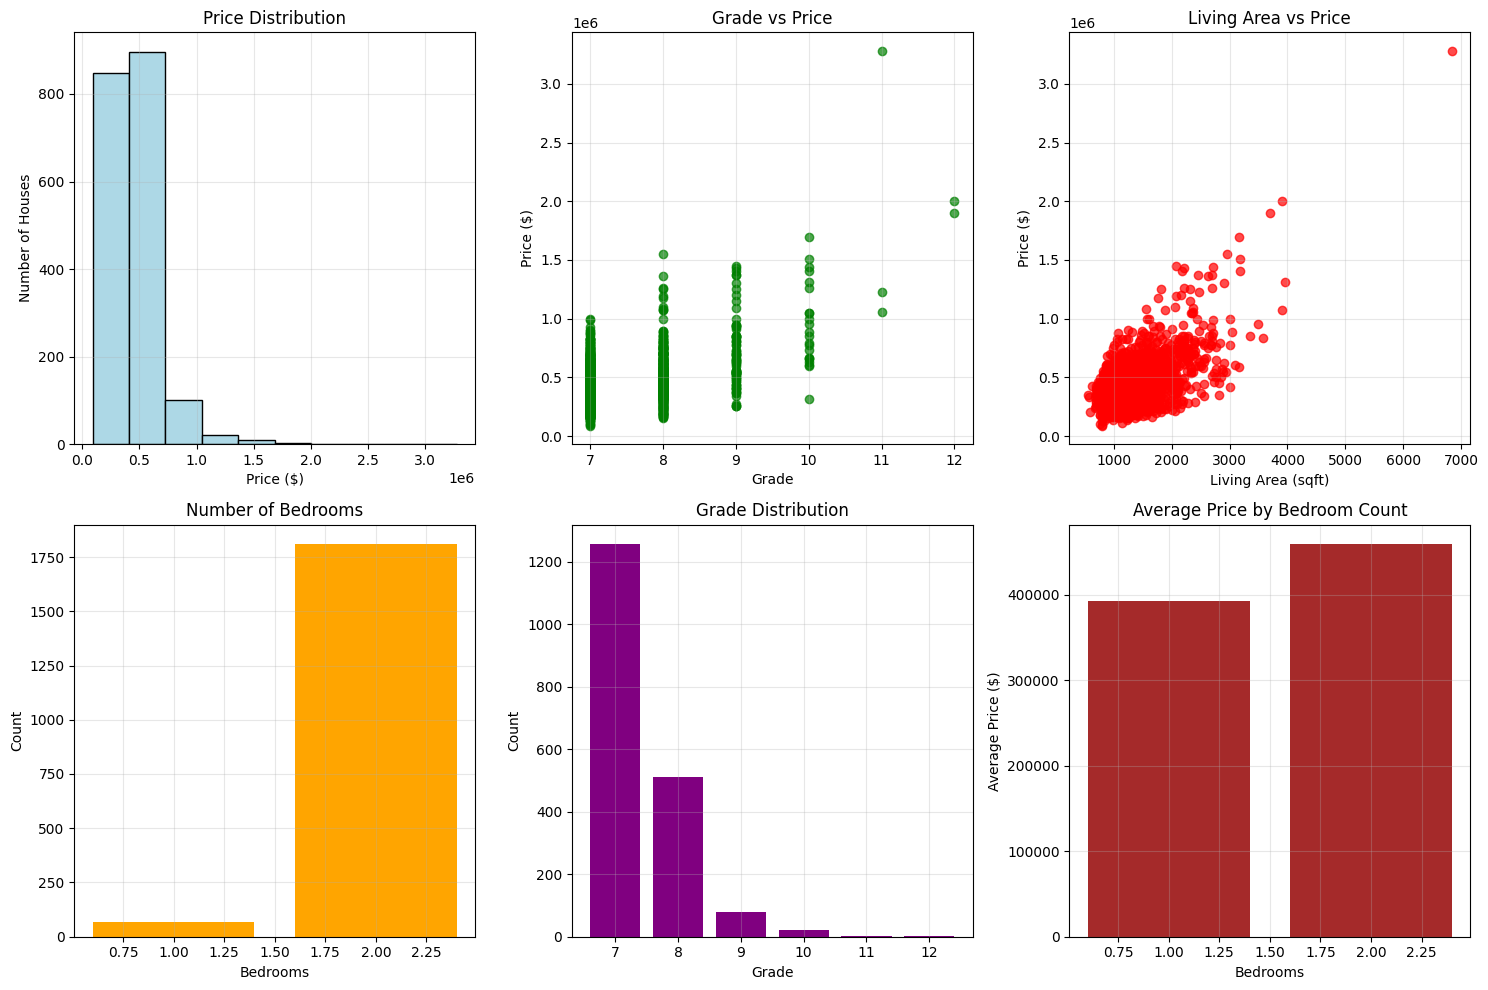


=== SUMMARY TABLE ===
      date       price  bedrooms  bathrooms  grade  sqft_living  yr_built
2014-05-13   90000.000     2.000      1.000      7      790.000      1973
2014-12-12   95000.000     2.000      1.000      7      800.000      1947
2014-07-17  100000.000     2.000      1.000      7      770.000      1978
2014-07-08  115000.000     1.000      2.000      7     1150.000      1962
2015-04-16  130000.000     2.000      1.000      7      790.000      1951
2014-10-21  130000.000     2.000      1.000      7      840.000      1951
2014-05-08  134000.000     2.000      1.500      7      980.000      1922
2015-03-24  139500.000     2.000      1.500      7     1230.000      1983
2015-02-17  149900.000     2.000      1.750      8     1090.000      1982
2015-03-24  150000.000     2.000      1.000      7     1250.000      1951
2014-05-22  150000.000     2.000      1.000      7      820.000      1954
2014-07-22  150000.000     2.000      1.500      7     1360.000      1978
2014-10-09  153

In [45]:
# Step 5: Create visualizations
print("\nCreating plots...")

# Create a figure with multiple plots
plt.figure(figsize=(15, 10))

# Plot 1: Price distribution
plt.subplot(2, 3, 1)
plt.hist(good_houses['price'], bins=10, color='lightblue', edgecolor='black')
plt.title('Price Distribution')
plt.xlabel('Price ($)')
plt.ylabel('Number of Houses')
plt.grid(True, alpha=0.3)

# Plot 2: Grade vs Price
plt.subplot(2, 3, 2)
plt.scatter(good_houses['grade'], good_houses['price'], color='green', alpha=0.7)
plt.title('Grade vs Price')
plt.xlabel('Grade')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Plot 3: Living Area vs Price
plt.subplot(2, 3, 3)
plt.scatter(good_houses['sqft_living'], good_houses['price'], color='red', alpha=0.7)
plt.title('Living Area vs Price')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.grid(True, alpha=0.3)

# Plot 4: Bedroom count
plt.subplot(2, 3, 4)
bedroom_counts = good_houses['bedrooms'].value_counts().sort_index()
plt.bar(bedroom_counts.index, bedroom_counts.values, color='orange')
plt.title('Number of Bedrooms')
plt.xlabel('Bedrooms')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Plot 5: Grade distribution
plt.subplot(2, 3, 5)
grade_counts = good_houses['grade'].value_counts().sort_index()
plt.bar(grade_counts.index, grade_counts.values, color='purple')
plt.title('Grade Distribution')
plt.xlabel('Grade')
plt.ylabel('Count')
plt.grid(True, alpha=0.3)

# Plot 6: Price by bedroom count
plt.subplot(2, 3, 6)
price_by_bedrooms = good_houses.groupby('bedrooms')['price'].mean()
plt.bar(price_by_bedrooms.index, price_by_bedrooms.values, color='brown')
plt.title('Average Price by Bedroom Count')
plt.xlabel('Bedrooms')
plt.ylabel('Average Price ($)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Step 6: Simple summary table
print("\n=== SUMMARY TABLE ===")
summary = good_houses[['date', 'price', 'bedrooms', 'bathrooms', 'grade', 'sqft_living', 'yr_built']].copy()
summary = summary.sort_values('price')  # Sort by price (lowest first)
print(summary.to_string(index=False))

print(f"\n🎉 Analysis complete! Found {len(good_houses)} perfect matches for your criteria.")


In [46]:
print(good_houses.head(2))

         date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
11 2014-05-27 468000.000     2.000      1.000     1160.000  6000.000       1   
18 2014-12-05 189000.000     2.000      1.000     1200.000  9850.000       1   

    waterfront  view  condition  ...     long  sqft_living15  sqft_lot15  \
11           0     0          4  ... -122.292       1330.000    6000.000   
18           0     0          4  ... -122.210       1060.000    5095.000   

             price_category  grade_category  bedroom_category  \
11  Mid-Range ($400K-$600K)        Good (8)        Medium (3)   
18          Budget (<$250K)        Good (8)        Medium (3)   

           location  month  month_name  year  
11  In Seattle City      5         May  2014  
18  Outside Seattle     12    December  2014  

[2 rows x 27 columns]


In [47]:
print(good_houses['zipcode'].unique())

[98115 98002 98030 98133 98117 98118 98056 98136 98198 98119 98027 98177
 98038 98144 98053 98166 98103 98006 98028 98122 98105 98112 98116 98188
 98004 98092 98106 98126 98199 98045 98102 98065 98042 98075 98003 98070
 98001 98024 98023 98022 98146 98155 98107 98058 98108 98007 98052 98168
 98014 98034 98033 98125 98178 98077 98008 98019 98072 98109 98032 98055
 98029 98074 98010 98040 98011 98031 98148 98059 98039 98005]


In [48]:
print("=== ZIPCODE ANALYSIS ===")
print("Unique zipcodes in dataset:")
print(good_houses['zipcode'].unique())
unique_zipcodes = sorted(good_houses['zipcode'].unique())
print(f"Unique zipcodes in your dataset: {unique_zipcodes}")
print(f"Number of properties: {len(good_houses)}")
print(f"Number of unique zipcodes: {len(unique_zipcodes)}")

# Check the geographic spread
print(f"\nGeographic range:")
print(f"Latitude: {good_houses['lat'].min():.4f} to {good_houses['lat'].max():.4f}")
print(f"Longitude: {good_houses['long'].min():.4f} to {good_houses['long'].max():.4f}")

# We need to understand the geographic distribution and identify which zipcodes correspond to the city center vs. suburban/rural areas.

# Count how many properties are in each zipcode and print them in order

## df['zipcode'] selects the zipcode column from the DataFrame.
## .value_counts() counts how many times each zipcode appears (i.e., how many properties exist in each zipcode).
## .sort_index() sorts the results by zipcode number (ascending order), instead of sorting by count.

zipcode_counts = good_houses['zipcode'].value_counts().sort_index()


# Step 2: Define Seattle city zipcodes based on your actual data
# From your dataset, I can see both Seattle (981xx) and suburban (980xx) zipcodes

# df3['zipcode'].unique()
## Extracts the zipcode column from df3.
## .unique() returns a NumPy array of all unique zipcodes in the dataset.
seattle_zipcodes = {z for z in good_houses['zipcode'].unique() if 98100 <= z <= 98199}
suburban_zipcodes = {z for z in good_houses['zipcode'].unique() if 98000 <= z <= 98099}

# Step 3: Classify each house as "In City" or "Outside City"
print("\n Step 3: Classifying houses...")

def where_is_house(zipcode):
    """Simple function to check if a house is in Seattle or outside"""
    if zipcode in seattle_zipcodes:
        return "In Seattle City"
    else:
        return "Outside Seattle"
    
# Make a new dataframe so the original one_two_bedrooms is NOT changed
df_bedroom_loc = good_houses.copy()

# Add the new 'location' column to the NEW dataframe
df_bedroom_loc['location'] = df_bedroom_loc['zipcode'].apply(where_is_house)

# Apply the classification to each row
df_bedroom_loc['location'] = df_bedroom_loc['zipcode'].apply(where_is_house)

# Count how many houses in each category
location_counts = df_bedroom_loc['location'].value_counts()
print("House locations:")
for location, count in location_counts.items():
    print(f"  {location}: {count} houses")

# Separate houses based on location: Country or City

df_bedroom_country = df_bedroom_loc[df_bedroom_loc['location'] == "Outside Seattle"]
print(len(df_bedroom_country.index))

df_bedroom_city = df_bedroom_loc[df_bedroom_loc['location'] != "Outside Seattle"]
print(len(df_bedroom_city.index))

=== ZIPCODE ANALYSIS ===
Unique zipcodes in dataset:
[98115 98002 98030 98133 98117 98118 98056 98136 98198 98119 98027 98177
 98038 98144 98053 98166 98103 98006 98028 98122 98105 98112 98116 98188
 98004 98092 98106 98126 98199 98045 98102 98065 98042 98075 98003 98070
 98001 98024 98023 98022 98146 98155 98107 98058 98108 98007 98052 98168
 98014 98034 98033 98125 98178 98077 98008 98019 98072 98109 98032 98055
 98029 98074 98010 98040 98011 98031 98148 98059 98039 98005]
Unique zipcodes in your dataset: [np.int64(98001), np.int64(98002), np.int64(98003), np.int64(98004), np.int64(98005), np.int64(98006), np.int64(98007), np.int64(98008), np.int64(98010), np.int64(98011), np.int64(98014), np.int64(98019), np.int64(98022), np.int64(98023), np.int64(98024), np.int64(98027), np.int64(98028), np.int64(98029), np.int64(98030), np.int64(98031), np.int64(98032), np.int64(98033), np.int64(98034), np.int64(98038), np.int64(98039), np.int64(98040), np.int64(98042), np.int64(98045), np.int64(9

### Selecting country house

In [49]:
# -------Finding county houses in the right season and non renovated --------
# Step 2a: Find houses sold in March, April, or May
print("\nStep 1: Finding houses sold in Spring months...")

# for county houses
## Select houses sold in Spring (Mar-May)
## Select houses that are non renovated

# Make a new dataframe so the original df_bedroom is NOT changed
df_bdrm_cntry_time = df_bedroom_country.copy()

# Spring months: March=3, April=4, May=5
spring_months = [3, 4, 5]
spring_houses = df_bdrm_cntry_time[df_bdrm_cntry_time['month'].isin(spring_months)]

print(f"Found {len(spring_houses)} houses sold in March, April, or May")


Step 1: Finding houses sold in Spring months...
Found 159 houses sold in March, April, or May


In [53]:
print(spring_houses.head(5))

          date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
23  2014-05-16 252700.000     2.000      1.500     1070.000  9643.000       1   
88  2014-05-19 215000.000     2.000      2.250     1610.000  2040.000       2   
226 2015-03-09 479950.000     2.000      2.000     1510.000  6516.000       1   
395 2015-04-30 330000.000     2.000      1.000     1220.000 10000.000       1   
531 2015-05-05 200000.000     2.000      1.500     1360.000  1898.000       2   

     waterfront  view  condition  ...     long  sqft_living15  sqft_lot15  \
23            0     0          3  ... -122.166       1220.000    8386.000   
88            0     0          4  ... -122.194       1950.000    2025.000   
226           0     0          3  ... -122.013       1640.000    6009.000   
395           0     0          5  ... -122.241       2000.000    9600.000   
531           0     0          3  ... -122.190       1360.000    1898.000   

               price_category  grade_category  bed

In [54]:
print("\nStep 2: Finding houses that are not renovated")

# Step 3: Filter for NOT renovated (yr_renovated is 0 or NaN)
# In this dataset, 0.0 means not renovated, and NaN might also mean not renovated
not_renovated_houses = spring_houses[(spring_houses['yr_renovated'] == 0) | (spring_houses['yr_renovated'].isna())]
print(f"Found {len(not_renovated_houses)} houses that are NOT renovated\n")


Step 2: Finding houses that are not renovated
Found 152 houses that are NOT renovated



In [55]:
print("\n=== STATISTICS ===")
if len(not_renovated_houses) > 0:
    print(f"Total matching houses: {len(not_renovated_houses)}")
    print(f"Average price: ${not_renovated_houses['price'].mean():,.0f}")
    print(f"Minimum price: ${not_renovated_houses['price'].min():,.0f}")
    print(f"Maximum price: ${not_renovated_houses['price'].max():,.0f}")
    print(f"Average living area: {not_renovated_houses['sqft_living'].mean():.0f} sqft")
    print(f"Average grade: {not_renovated_houses['grade'].mean():.1f}")
    
    # Year built statistics
    print(f"Oldest house: {not_renovated_houses['yr_built'].min():.0f}")
    print(f"Newest house: {not_renovated_houses['yr_built'].max():.0f}")
    print(f"Average year built: {not_renovated_houses['yr_built'].mean():.0f}")
else:
    print("No statistics available - no matching houses found.")


=== STATISTICS ===
Total matching houses: 152
Average price: $455,216
Minimum price: $90,000
Maximum price: $2,000,000
Average living area: 1607 sqft
Average grade: 7.6
Oldest house: 1920
Newest house: 2014
Average year built: 1986



Creating plots...


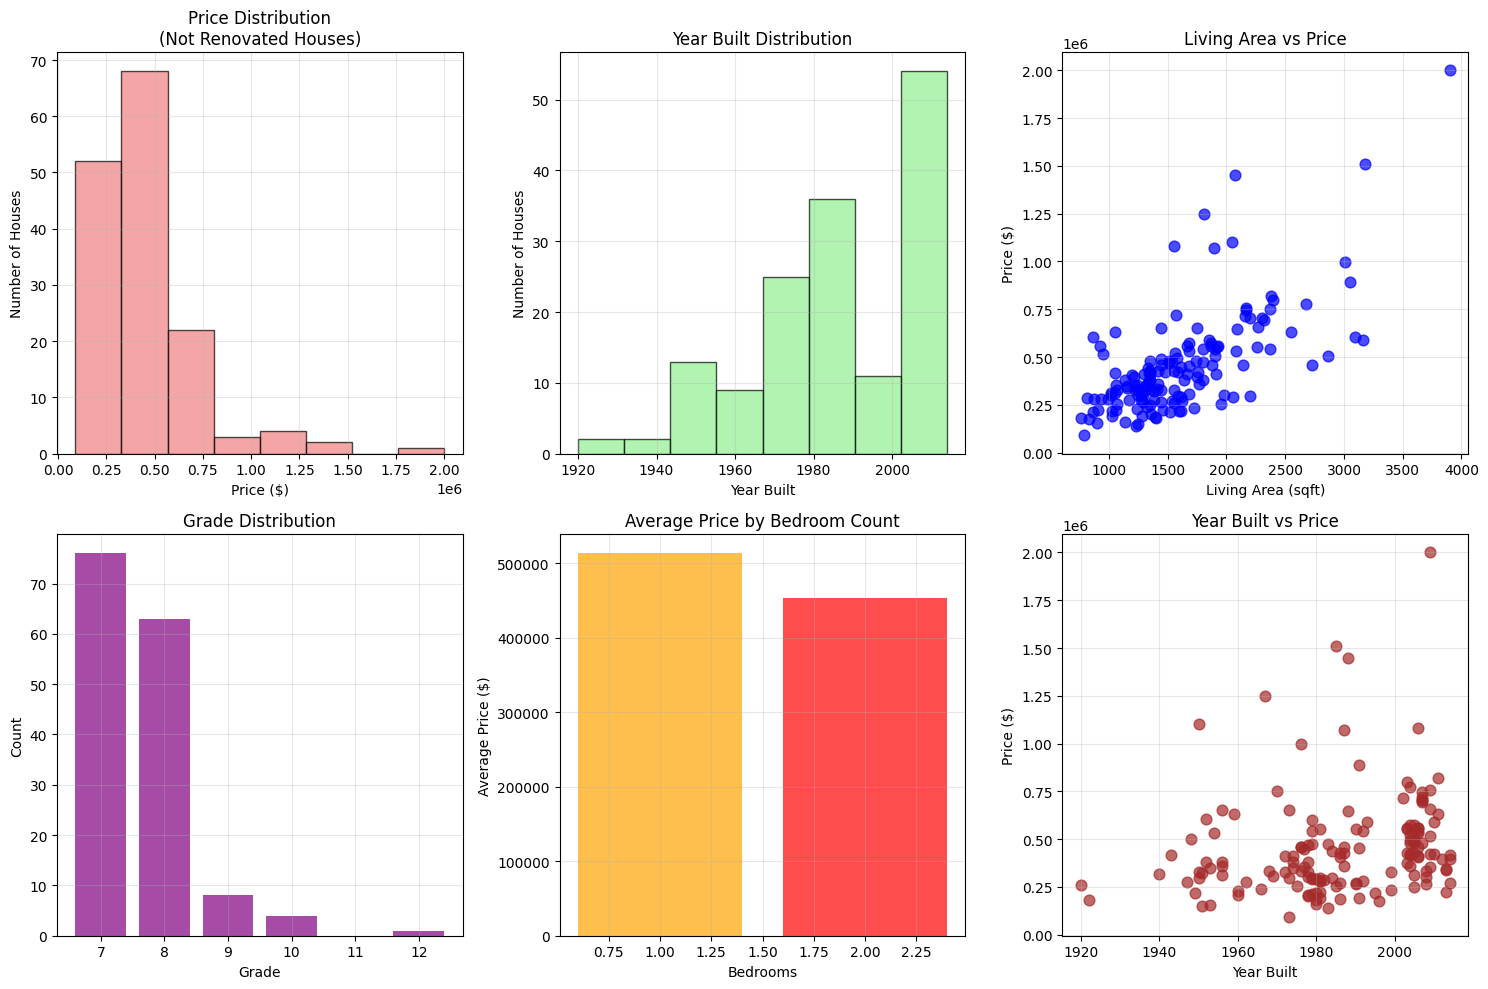


=== SUMMARY TABLE ===
      date       price  bedrooms  bathrooms  grade  sqft_living  yr_built  zipcode
2014-05-13   90000.000     2.000      1.000      7      790.000      1973    98034
2015-03-24  139500.000     2.000      1.500      7     1230.000      1983    98042
2015-03-24  150000.000     2.000      1.000      7     1250.000      1951    98002
2015-03-24  157340.000     2.000      1.000      7      900.000      1953    98042
2015-04-27  160000.000     2.000      1.000      8     1140.000      1980    98028
2014-05-28  175000.000     2.000      1.000      7      830.000      1996    98038
2014-05-22  180000.000     2.000      1.000      7     1400.000      1922    98055
2015-03-26  183000.000     2.000      1.000      7      760.000      1980    98003
2014-05-28  186950.000     2.000      2.000      7     1390.000      1986    98003
2015-04-15  189950.000     2.000      1.000      8     1030.000      1981    98038
2015-03-20  193000.000     2.000      1.750      7     1280.000 

In [56]:
# Step 6: Create visualizations
if len(not_renovated_houses) > 0:
    print("\nCreating plots...")
    
    # Create a figure with multiple plots
    plt.figure(figsize=(15, 10))
    
    # Plot 1: Price distribution
    plt.subplot(2, 3, 1)
    plt.hist(not_renovated_houses['price'], bins=8, color='lightcoral', edgecolor='black', alpha=0.7)
    plt.title('Price Distribution\n(Not Renovated Houses)')
    plt.xlabel('Price ($)')
    plt.ylabel('Number of Houses')
    plt.grid(True, alpha=0.3)
    
    # Plot 2: Year built distribution
    plt.subplot(2, 3, 2)
    plt.hist(not_renovated_houses['yr_built'], bins=8, color='lightgreen', edgecolor='black', alpha=0.7)
    plt.title('Year Built Distribution')
    plt.xlabel('Year Built')
    plt.ylabel('Number of Houses')
    plt.grid(True, alpha=0.3)
    
    # Plot 3: Living Area vs Price
    plt.subplot(2, 3, 3)
    plt.scatter(not_renovated_houses['sqft_living'], not_renovated_houses['price'], 
               color='blue', alpha=0.7, s=60)
    plt.title('Living Area vs Price')
    plt.xlabel('Living Area (sqft)')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    
    # Plot 4: Grade distribution
    plt.subplot(2, 3, 4)
    grade_counts = not_renovated_houses['grade'].value_counts().sort_index()
    plt.bar(grade_counts.index, grade_counts.values, color='purple', alpha=0.7)
    plt.title('Grade Distribution')
    plt.xlabel('Grade')
    plt.ylabel('Count')
    plt.grid(True, alpha=0.3)
    
    # Plot 5: Price by bedroom count
    plt.subplot(2, 3, 5)
    price_by_bedrooms = not_renovated_houses.groupby('bedrooms')['price'].mean()
    colors = ['orange', 'red']
    plt.bar(price_by_bedrooms.index, price_by_bedrooms.values, color=colors[:len(price_by_bedrooms)], alpha=0.7)
    plt.title('Average Price by Bedroom Count')
    plt.xlabel('Bedrooms')
    plt.ylabel('Average Price ($)')
    plt.grid(True, alpha=0.3)
    
    # Plot 6: Year built vs Price
    plt.subplot(2, 3, 6)
    plt.scatter(not_renovated_houses['yr_built'], not_renovated_houses['price'], 
               color='brown', alpha=0.7, s=60)
    plt.title('Year Built vs Price')
    plt.xlabel('Year Built')
    plt.ylabel('Price ($)')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Step 7: Simple summary table
    print("\n=== SUMMARY TABLE ===")
    summary = not_renovated_houses[['date', 'price', 'bedrooms', 'bathrooms', 'grade', 
                                  'sqft_living', 'yr_built', 'zipcode']].copy()
    summary = summary.sort_values('price')  # Sort by price (lowest first)
    print(summary.to_string(index=False))
    
    print(f"\n✅ Analysis complete! Found {len(not_renovated_houses)} houses matching all criteria.")
else:
    print("\n❌ No houses found matching all criteria.")

# Additional: Show what criteria filtered out houses
print("\n=== FILTERING BREAKDOWN ===")
print(f"Total houses in dataset: {len(df_eda)}")
print(f"After 1-2 bedroom filter: {len(one_two_bedrooms)}")
print(f"After grade 7+ filter: {len(good_houses)}")
print(f"After not-renovated filter: {len(not_renovated_houses)}")


In [62]:
# get price_category and grade 
price_category = not_renovated_houses['price_category'].unique()
print(price_category)

grade_category = not_renovated_houses['grade_category'].unique()
print(grade_category)


['Affordable ($250K-$400K)', 'Budget (<$250K)', 'Mid-Range ($400K-$600K)', 'Premium ($600K-$1M)', 'Luxury (>$1M)']
Categories (5, object): ['Budget (<$250K)' < 'Affordable ($250K-$400K)' < 'Mid-Range ($400K-$600K)' < 'Premium ($600K-$1M)' < 'Luxury (>$1M)']
['Good (8)', 'Very Good (9)', 'Luxury (11+)', 'Excellent (10)']
Categories (6, object): ['Below Average (1-6)' < 'Average (7)' < 'Good (8)' < 'Very Good (9)' < 'Excellent (10)' < 'Luxury (11+)']


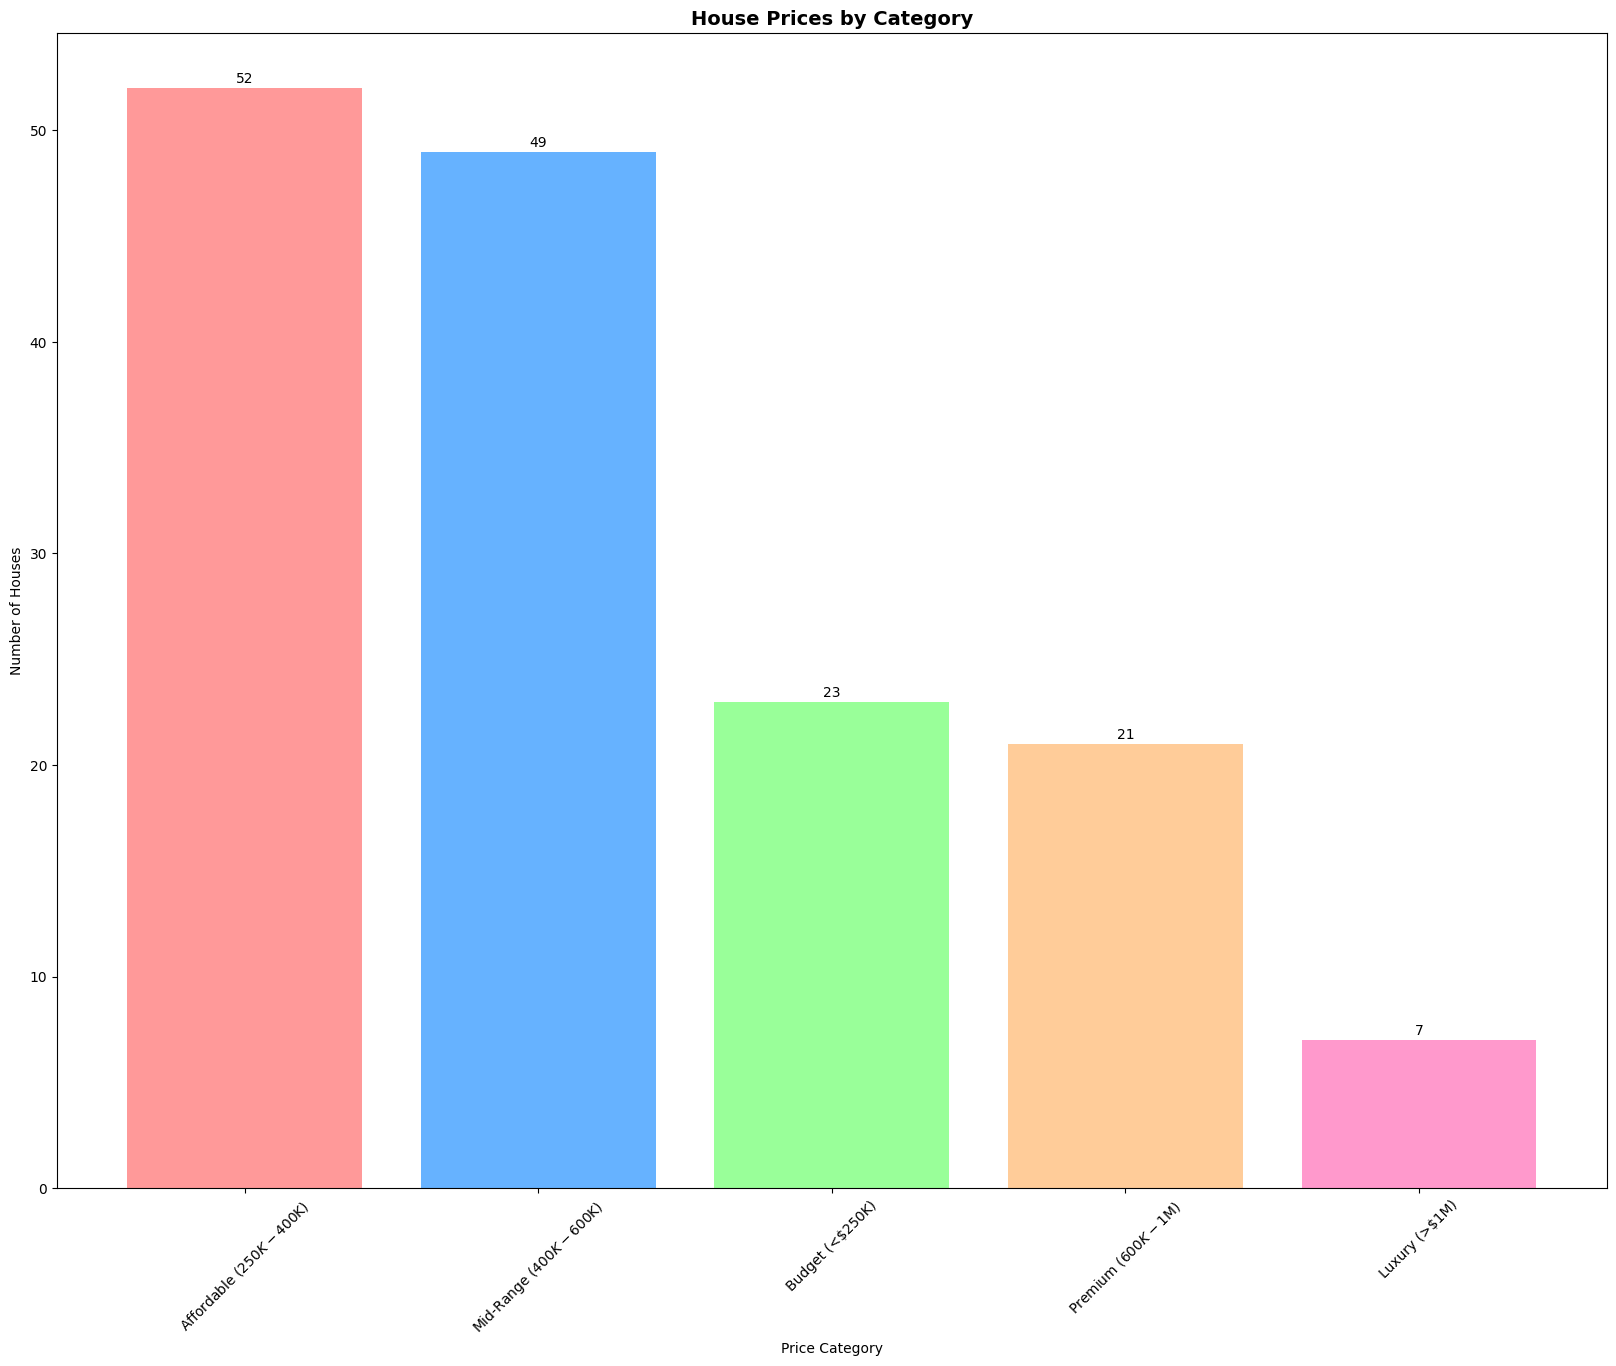

In [63]:
# Create a big figure with all our plots
plt.figure(figsize=(20, 15))

# Plot 1: Bar Chart - Price Categories
#plt.subplot(2, 3, 1)
price_counts = not_renovated_houses['price_category'].value_counts()
colors1 = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
plt.bar(price_counts.index, price_counts.values, color=colors1)
plt.title('House Prices by Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on top of bars
for i, count in enumerate(price_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')


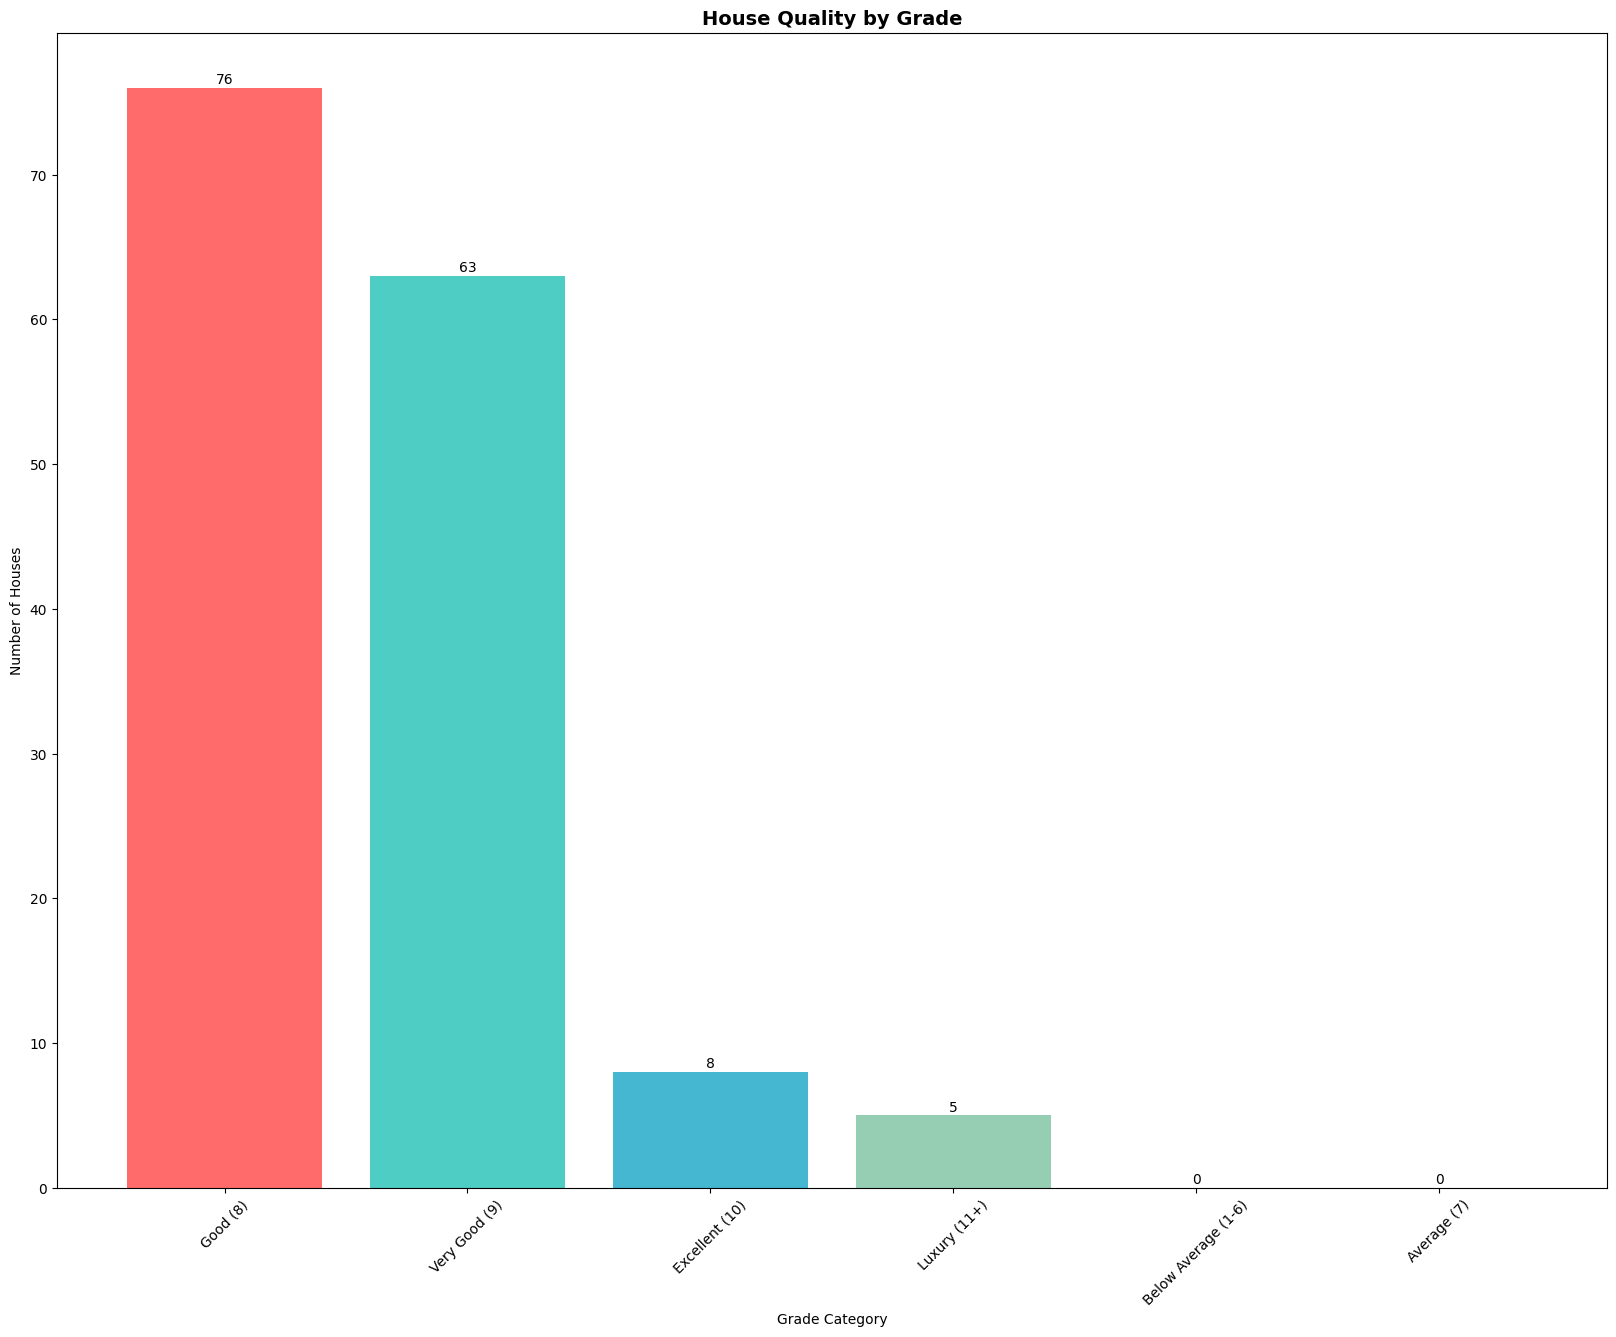

In [64]:
# Create a big figure with all our plots
plt.figure(figsize=(20, 15))

# Plot 2: Bar Chart - Grade Categories
grade_counts =  not_renovated_houses['grade_category'].value_counts()
colors2 = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57']
plt.bar(grade_counts.index, grade_counts.values, color=colors2)
plt.title('House Quality by Grade', fontsize=14, fontweight='bold')
plt.xlabel('Grade Category')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on top of bars
for i, count in enumerate(grade_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom')


In [66]:
print(not_renovated_houses.head(5))

          date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
23  2014-05-16 252700.000     2.000      1.500     1070.000  9643.000       1   
88  2014-05-19 215000.000     2.000      2.250     1610.000  2040.000       2   
226 2015-03-09 479950.000     2.000      2.000     1510.000  6516.000       1   
395 2015-04-30 330000.000     2.000      1.000     1220.000 10000.000       1   
531 2015-05-05 200000.000     2.000      1.500     1360.000  1898.000       2   

     waterfront  view  condition  ...     long  sqft_living15  sqft_lot15  \
23            0     0          3  ... -122.166       1220.000    8386.000   
88            0     0          4  ... -122.194       1950.000    2025.000   
226           0     0          3  ... -122.013       1640.000    6009.000   
395           0     0          5  ... -122.241       2000.000    9600.000   
531           0     0          3  ... -122.190       1360.000    1898.000   

               price_category  grade_category  bed

In [71]:
## We have selected houses that are:
    ## With Grade: Good, Very Good and Excellent & Price Budget, Affordable, there were no houses

df_country_selected = not_renovated_houses[
    (not_renovated_houses['grade_category'].str.contains('Good|Very Good')) &
    (not_renovated_houses['price_category'].str.contains('Affordable|Mid-Range'))
]
print(f"Found {len(df_country_selected)} houses matching your criteria!")

Found 97 houses matching your criteria!


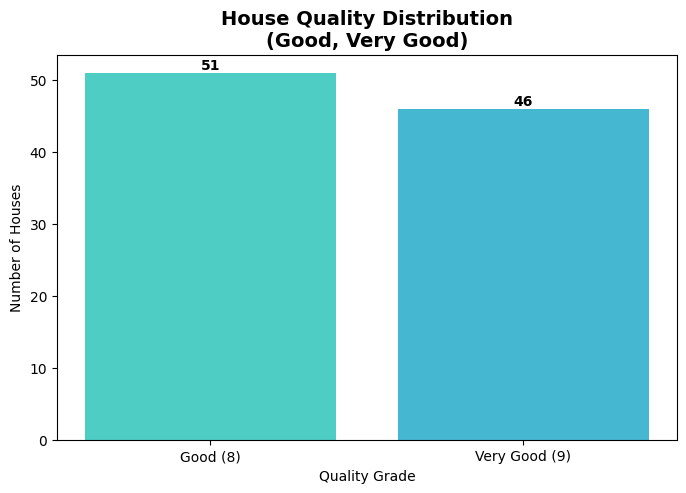

In [73]:
grade_counts = df_country_selected['grade_category'].value_counts()
# Filter out categories with 0 count
grade_counts = grade_counts[grade_counts > 0]


colors = ['#4ECDC4', '#45B7D1', '#96CEB4']  # Green-blue colors for quality
plt.bar(grade_counts.index, grade_counts.values, color=colors)
plt.title('House Quality Distribution\n(Good, Very Good)', fontsize=14, fontweight='bold')
plt.xlabel('Quality Grade')
plt.ylabel('Number of Houses')
    # Add numbers on bars
for i, count in enumerate(grade_counts.values):
        plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

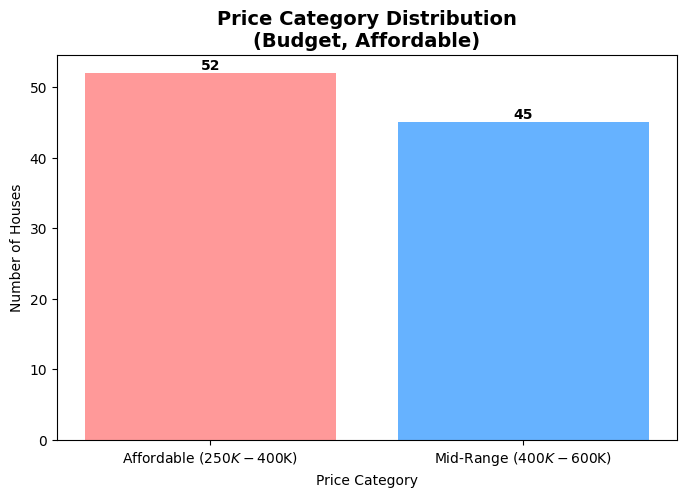

In [74]:
 #Chart 2: Bar Chart - Count by Price Category
 
price_counts = df_country_selected['price_category'].value_counts()
# remove entries where count == 0
price_counts = price_counts[price_counts > 0]

colors = ['#FF9999', '#66B2FF']  # Red-blue colors for price
plt.bar(price_counts.index, price_counts.values, color=colors)
plt.title('Price Category Distribution\n(Budget, Affordable)', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Number of Houses')
    # Add numbers on bars
for i, count in enumerate(price_counts.values):
        plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

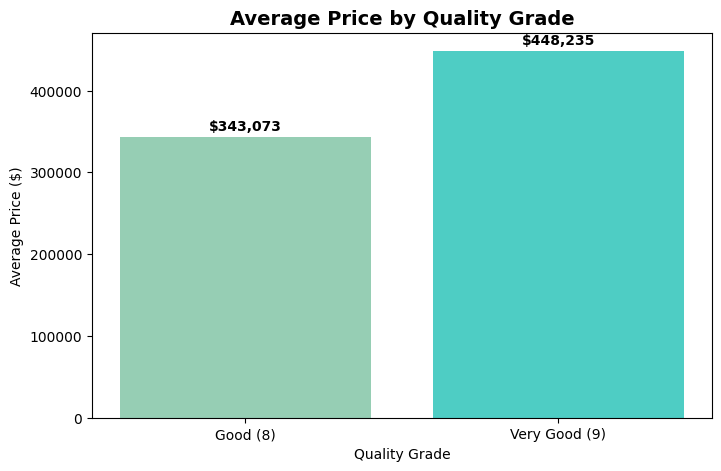

In [77]:
# Chart 3: Bar Chart - Average Price by Grade

avg_price_by_grade = df_country_selected.groupby('grade_category')['price'].mean()
colors_avg = ['#4ECDC4', '#45B7D1', '#96CEB4']
plt.bar(avg_price_by_grade.index, avg_price_by_grade.values, color=colors_avg)
plt.title('Average Price by Quality Grade', fontsize=14, fontweight='bold')
plt.xlabel('Quality Grade')
plt.ylabel('Average Price ($)')
    # Add values on bars
for i, price in enumerate(avg_price_by_grade.values):
        plt.text(i, price + 5000, f'${price:,.0f}', ha='center', va='bottom', fontweight='bold')

Text(0.5, 1.0, 'Quality vs Price Combination')

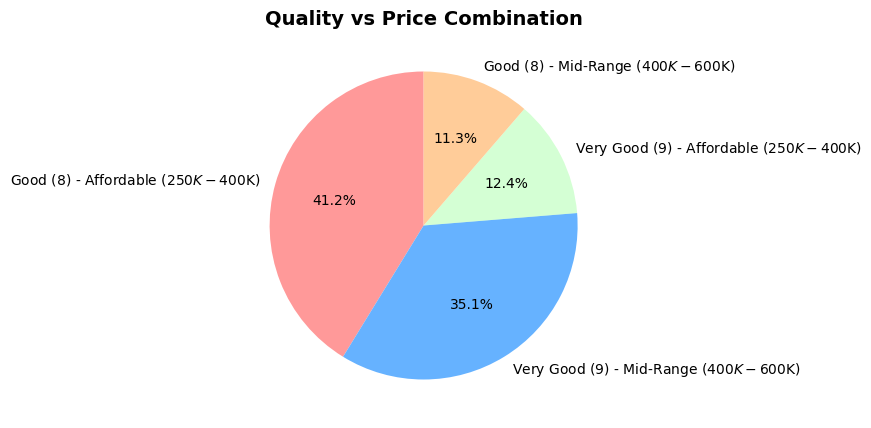

In [ ]:
# Chart 4: Pie Chart - Grade vs Price Combination

df_country_selected['grade_price'] = (
    df_country_selected['grade_category'].astype(str)
    + ' - ' +
    df_country_selected['price_category'].astype(str)
)

combo_counts = df_country_selected['grade_price'].value_counts()



combo_counts = df_country_selected['grade_price'].value_counts()
colors_pie = ['#FF9999', '#66B2FF', "#99FF996B", '#FFCC99', '#FF99CC', '#C9C9FF']
plt.pie(combo_counts.values, labels=combo_counts.index, autopct='%1.1f%%', 
            colors=colors_pie[:len(combo_counts)], startangle=90)
plt.title('Quality vs Price Combination', fontsize=14, fontweight='bold')


In [78]:
print(combo_counts.head())

grade_price
Good (8) - Affordable ($250K-$400K)         40
Very Good (9) - Mid-Range ($400K-$600K)     34
Very Good (9) - Affordable ($250K-$400K)    12
Good (8) - Mid-Range ($400K-$600K)          11
Name: count, dtype: int64


In [ ]:
# Selecting houses that are Affordable and grade very good
df_country_premium = df_country_selected[
    (df_country_selected['grade_category'].str.contains('Very Good')) &
    (df_country_selected['price_category'].str.contains('Affordable'))
]
print(f"Found {len(df_country_premium)} houses matching your criteria!")

Found 12 houses matching your criteria!


In [82]:
# Now lets check for nice to have features

waterfront = df_country_premium['waterfront'].unique()
print(waterfront)

view = df_country_premium['view'].unique()
print(view)

yr_built = df_country_premium['year'].unique()
print(yr_built)

[0]
[0]
[2015 2014]


In [84]:
# We select houses that are built in 2015

top_country_houses = df_country_premium[
    df_country_premium['year'] ==2015]

print(f"Found {len(top_city_houses)} houses matching your criteria!")

Found 11 houses matching your criteria!


In [86]:
print("Creating Charts for Houses by Bedrooms, Living Area, and Price")
print("=" * 60)

# Step 1: Load the data
top_country_houses['price'] = pd.to_numeric(top_country_houses['price'], errors='coerce')
# Here we only have 2 bedrooms, so we leave out the following query
#df_country_2015['bedrooms'] = pd.to_numeric(df_country_2015['bedrooms'], errors='coerce')
top_country_houses['sqft_living15'] = pd.to_numeric(top_country_houses['sqft_living15'], errors='coerce')

print(f"Loaded {len(top_country_houses)} df_country_2015")
#print(f"Bedrooms range: {df_country_2015['bedrooms'].min()} to {df_country_2015['bedrooms'].max()}")
print(f"Living area range: {top_country_houses['sqft_living15'].min()} to {top_country_houses['sqft_living15'].max()} sqft")
print(f"Price range: ${top_country_houses['price'].min():,} to ${top_country_houses['price'].max():,}")


Creating Charts for Houses by Bedrooms, Living Area, and Price
Loaded 11 df_country_2015
Living area range: 1310.0 to 2370.0 sqft
Price range: $255,000.0 to $395,000.0


In [87]:
# Step 2: Create categories for sqft_living15
def get_living_area_category(sqft):
    if sqft < 1000:
        return "Small (<1000 sqft)"
    elif sqft < 1500:
        return "Medium (1000-1500 sqft)"
    elif sqft < 2000:
        return "Large (1500-2000 sqft)"
    elif sqft < 2500:
        return "Extra Large (2000-2500 sqft)"
    else:
        return "Huge (>2500 sqft)"

top_country_houses['living_area_category'] = top_country_houses['sqft_living15'].apply(get_living_area_category)

print(f"\nCreated categories for {len(top_country_houses)} houses")
print("Living Area Categories:", top_country_houses['living_area_category'].unique())


Created categories for 11 houses
Living Area Categories: ['Extra Large (2000-2500 sqft)' 'Large (1500-2000 sqft)'
 'Medium (1000-1500 sqft)']


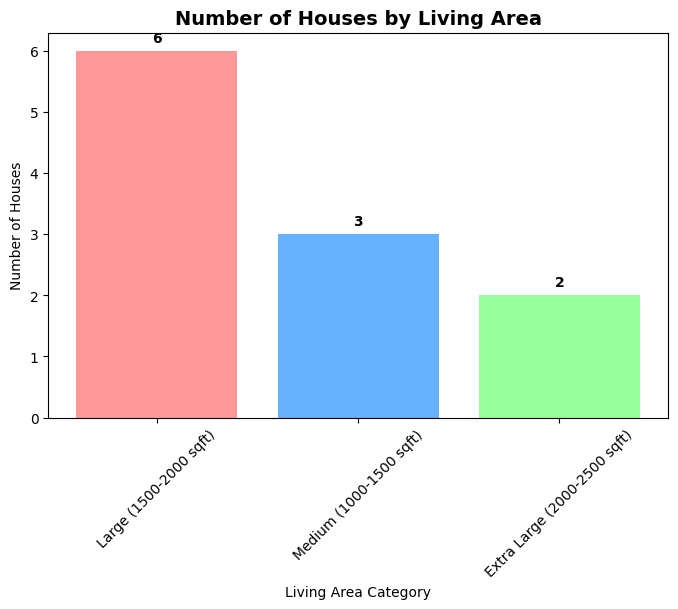

In [88]:
# Chart: Bar Chart - Number of houses by living area category

area_counts = top_country_houses['living_area_category'].value_counts()
colors2 = ['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC']
plt.bar(area_counts.index, area_counts.values, color=colors2)
plt.title('Number of Houses by Living Area', fontsize=14, fontweight='bold')
plt.xlabel('Living Area Category')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on bars
for i, count in enumerate(area_counts.values):
    plt.text(i, count + 0.1, str(count), ha='center', va='bottom', fontweight='bold')

In [93]:
# Filter for Medium living area category
medium_houses = top_country_houses[top_country_houses['living_area_category'].str.contains('Medium')]

print(f" Found {len(medium_houses)} houses in Medium living area category")

 Found 3 houses in Medium living area category


In [94]:
print(medium_houses.head(5))

            date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
7015  2015-03-23 330000.000     2.000      1.500     1440.000 11954.000   
7520  2015-04-07 376000.000     2.000      2.000     1340.000  1635.000   
12311 2015-04-29 330000.000     2.000      2.500     1310.000  2915.000   

       floors  waterfront  view  condition  ...  sqft_lot15  \
7015        1           0     0          4  ...    9730.000   
7520        2           0     0          3  ...    1375.000   
12311       2           0     0          3  ...    3425.000   

                 price_category  grade_category  bedroom_category  \
7015   Affordable ($250K-$400K)   Very Good (9)        Medium (3)   
7520   Affordable ($250K-$400K)   Very Good (9)        Medium (3)   
12311  Affordable ($250K-$400K)   Very Good (9)        Medium (3)   

              location  month  month_name  year  \
7015   Outside Seattle      3       March  2015   
7520   Outside Seattle      4       April  2015   
12311  Outside S

In [95]:
# Create the map for country houses
print("\n Creating the map...")

# Find the middle point of all houses for centering the map
middle_lat = medium_houses['lat'].mean()
middle_long = medium_houses['long'].mean()

# Create a basic map
country_house_map = folium.Map(location=[middle_lat, middle_long], zoom_start=10)


 Creating the map...


In [96]:
# Add house markers to the map
print("Adding house markers to map...")

# Colors for different locations
colors = {
    "In Seattle City": "blue",
    "Outside Seattle": "red"
}

# Icons for different locations
icons = {
    "In Seattle City": "home",
    "Outside Seattle": "globe"
}

for index, house in medium_houses.iterrows():
    # Create a popup with house information
    popup_text = f"""
    <b>Location:</b> {house['location']}<br>
    <b>Price:</b> ${house['price']:,.0f}<br>
    <b>Zipcode:</b> {int(house['zipcode'])}<br>
    <b>Bedrooms:</b> {int(house['bedrooms'])}<br>
    <b>Bathrooms:</b> {house['bathrooms']}<br>
    <b>Size:</b> {int(house['sqft_living'])} sqft
    """
    
    # Add marker to map
    folium.Marker(
        location=[house['lat'], house['long']],
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"${house['price']:,.0f} - {house['location']}",
        icon=folium.Icon(
            color=colors[house['location']],
            icon=icons[house['location']],
            prefix='fa'
        )
    ).add_to(country_house_map)


Adding house markers to map...


In [97]:
# Add a legend to the map
print(" Adding legend...")

legend_html = '''
<div style="position: fixed; 
            top: 10px; left: 50px; width: 200px; 
            background: white; border: 2px solid grey; 
            padding: 10px; font-size: 14px; z-index: 9999;">
    <h4 style="margin: 0 0 8px 0;">House Locations</h4>
    <p style="margin: 2px 0;">
        <i class="fa fa-home" style="color: blue"></i> In Seattle City
    </p>
    <p style="margin: 2px 0;">
        <i class="fa fa-globe" style="color: red"></i> Outside Seattle
    </p>
</div>
'''

country_house_map.get_root().html.add_child(folium.Element(legend_html))

 Adding legend...


In [99]:
# Save the map
## This is a HUGE image with too many points
country_house_map.save("country_house_locations.html")

# configure chrome
options = Options()
options.add_argument("--headless")
driver = webdriver.Chrome(options=options)

# load the html
#driver.get("country_house_locations.html")
#time.sleep(3)   # wait for map tiles to load

# save screenshot
#driver.save_screenshot("map.png")
#driver.quit()
print(" Map saved as 'country_house_locations.html'")


 Map saved as 'country_house_locations.html'


### Selecting city house

In [100]:

print(df_bedroom_city.head(5))
print(df_bedroom_city.columns)

         date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
11 2014-05-27 468000.000     2.000      1.000     1160.000  6000.000       1   
31 2014-12-01 280000.000     2.000      1.500     1190.000  1265.000       3   
53 2015-02-05 585000.000     2.000      1.750     1980.000  8550.000       1   
82 2014-10-28 355000.000     2.000      1.000     2020.000  6720.000       1   
89 2014-09-04 335000.000     2.000      1.750     1030.000  1066.000       2   

    waterfront  view  condition  ...     long  sqft_living15  sqft_lot15  \
11           0     0          4  ... -122.292       1330.000    6000.000   
31           0     0          3  ... -122.357       1390.000    1756.000   
53           0     0          3  ... -122.369       1480.000    6738.000   
82           0     0          3  ... -122.291       1720.000    6720.000   
89           0     0          3  ... -122.387       1030.000    1106.000   

              price_category  grade_category  bedroom_category

In [101]:
# === Classify city center or outskirts (based on zipcodes)===

print(" ANALYZING ZIPCODES FOR CITY AREA CLASSIFICATION")
print("=" * 60)

# Step 1: Check what zipcodes we have
print(" ZIPCODE ANALYSIS:")
unique_zipcodes = sorted(df_bedroom_city['zipcode'].unique())
print(f"Total unique zipcodes: {len(unique_zipcodes)}")
print(f"Zipcode range: {min(unique_zipcodes)} to {max(unique_zipcodes)}")


 ANALYZING ZIPCODES FOR CITY AREA CLASSIFICATION
 ZIPCODE ANALYSIS:
Total unique zipcodes: 29
Zipcode range: 98102 to 98199


In [102]:
# Step 2: Count houses per zipcode
print(f"\n🏠 HOUSES PER ZIPCODE:")
zipcode_counts = df_bedroom_city['zipcode'].value_counts().sort_index()
print(f"Top 20 zipcodes by house count:")
for zipcode, count in zipcode_counts.head(20).items():
    print(f"  {zipcode}: {count} houses")


🏠 HOUSES PER ZIPCODE:
Top 20 zipcodes by house count:
  98102: 22 houses
  98103: 149 houses
  98105: 34 houses
  98106: 36 houses
  98107: 67 houses
  98108: 18 houses
  98109: 19 houses
  98112: 43 houses
  98115: 118 houses
  98116: 58 houses
  98117: 108 houses
  98118: 57 houses
  98119: 40 houses
  98122: 63 houses
  98125: 53 houses
  98126: 69 houses
  98133: 76 houses
  98136: 62 houses
  98144: 71 houses
  98146: 21 houses


In [104]:
# Step 3: Analyze price by zipcode
print(f"\n PRICE ANALYSIS BY ZIPCODE:")
zipcode_prices = df_bedroom_city.groupby('zipcode')['price'].agg(['mean', 'count']).sort_values('mean', ascending=False)
print("Top 10 most expensive zipcodes:")
for i, (zipcode, data) in enumerate(zipcode_prices.head(10).iterrows()):
    print(f"  {i+1:2}. {zipcode}: ${data['mean']:,.0f} ({data['count']} houses)")

print("\nTop 10 cheapest zipcodes:")
for i, (zipcode, data) in enumerate(zipcode_prices.tail(10).iterrows()):
    print(f"  {i+1:2}. {zipcode}: ${data['mean']:,.0f} ({data['count']} houses)")


 PRICE ANALYSIS BY ZIPCODE:
Top 10 most expensive zipcodes:
   1. 98166: $744,992 (6.0 houses)
   2. 98109: $684,711 (19.0 houses)
   3. 98112: $622,948 (43.0 houses)
   4. 98119: $615,679 (40.0 houses)
   5. 98199: $559,831 (55.0 houses)
   6. 98105: $558,211 (34.0 houses)
   7. 98102: $531,716 (22.0 houses)
   8. 98116: $523,378 (58.0 houses)
   9. 98146: $517,948 (21.0 houses)
  10. 98177: $515,544 (22.0 houses)

Top 10 cheapest zipcodes:
   1. 98126: $374,236 (69.0 houses)
   2. 98155: $366,950 (29.0 houses)
   3. 98108: $358,239 (18.0 houses)
   4. 98133: $341,271 (76.0 houses)
   5. 98178: $305,018 (19.0 houses)
   6. 98106: $295,901 (36.0 houses)
   7. 98188: $277,127 (11.0 houses)
   8. 98148: $241,925 (4.0 houses)
   9. 98168: $237,225 (16.0 houses)
  10. 98198: $230,273 (31.0 houses)


In [106]:
# Step 4: Create city area categories based on zipcode patterns
# Common Seattle area classification (you can adjust these)
def classify_city_area(zipcode):
    """Classify zipcodes into city areas based on known Seattle patterns"""
    
    # Downtown/Core urban areas
    downtown_zipcodes = [98101, 98104, 98121, 98122, 98134]
    
    # Central neighborhoods close to downtown
    central_zipcodes = [
        98102, 98103, 98105, 98107, 98108, 98109, 98112, 98115, 
        98116, 98117, 98118, 98119, 98125, 98126, 98133, 98136,
        98144, 98146, 98148, 98168, 98177, 98178, 98188, 98198, 98199
    ]

    # North Seattle areas
    north_zipcodes = [98125, 98133, 98155, 98177]
    
    # South Seattle areas  
    south_zipcodes = [98108, 98118, 98126, 98136, 98144, 98146, 98148, 98168, 98178, 98188, 98198]
    
    # Eastside suburbs (across Lake Washington)
    eastside_zipcodes = [98004, 98005, 98006, 98007, 98008, 98033, 98034, 98039, 98052, 98053, 98074]
    
    # Other suburbs and outskirts
    other_suburbs = [98001, 98002, 98003, 98010, 98011, 98014, 98019, 98022, 98023, 
                    98024, 98027, 98028, 98029, 98030, 98031, 98032, 98038, 98040, 
                    98042, 98045, 98055, 98056, 98058, 98059, 98065, 98070, 98072, 
                    98075, 98077, 98092]
    
    if zipcode in downtown_zipcodes:
        return "Downtown/Core"
    elif zipcode in central_zipcodes:
        return "Central City"
    elif zipcode in north_zipcodes:
        return "North Seattle"
    elif zipcode in south_zipcodes:
        return "South Seattle"
    elif zipcode in eastside_zipcodes:
        return "Eastside Suburbs"
    elif zipcode in other_suburbs:
        return "Outer Suburbs"
    else:
        return "Other Areas"

# Apply the classification
df_bedroom_city['city_area'] = df_bedroom_city['zipcode'].apply(classify_city_area)

print(f"\n CITY AREA CLASSIFICATION CREATED!")
print(f"Area categories: {df_bedroom_city['city_area'].unique()}")




 CITY AREA CLASSIFICATION CREATED!
Area categories: ['Central City' 'Other Areas' 'Downtown/Core' 'North Seattle']


In [107]:
# Step 5: Analyze each city area
print(f"\n ANALYSIS BY CITY AREA:")
area_stats = df_bedroom_city.groupby('city_area').agg({
    'price': ['count', 'mean', 'median'],
    'sqft_living': 'mean',
    'grade': 'mean',
    'bedrooms': 'mean'
}).round(2)

print(area_stats)


 ANALYSIS BY CITY AREA:
              price                       sqft_living grade bedrooms
              count       mean     median        mean  mean     mean
city_area                                                           
Central City   1243 462625.080 440000.000    1292.940 7.320    1.970
Downtown/Core    63 483682.130 440000.000    1179.410 7.630    1.920
North Seattle    29 366949.830 332000.000    1236.210 7.070    2.000
Other Areas      42 360057.140 302750.000    1316.170 7.600    1.930



 CREATING CITY AREA VISUALIZATIONS...


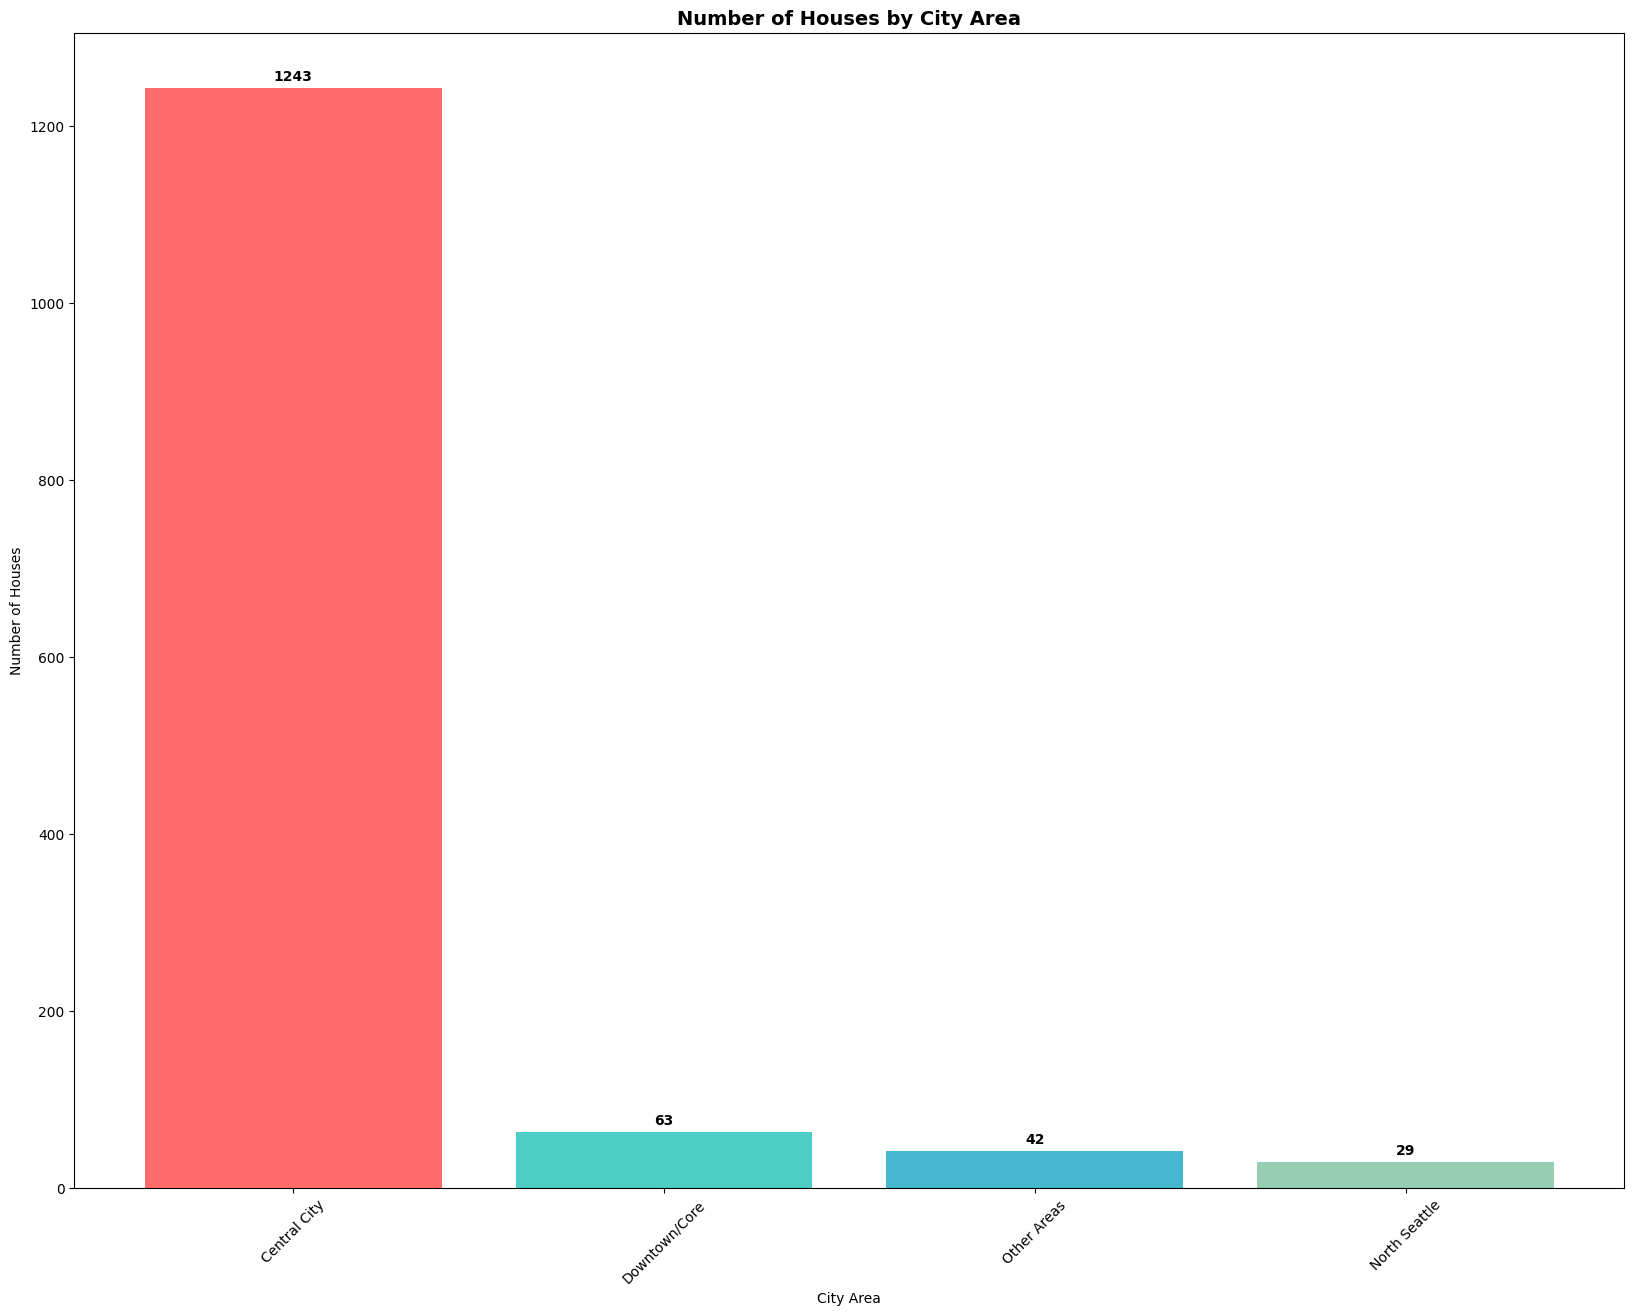

In [108]:
# Step 6: Create visualizations
print(f"\n CREATING CITY AREA VISUALIZATIONS...")

plt.figure(figsize=(20, 15))

# Chart 1: Number of houses by city area
#plt.subplot(3, 4, 1)
area_counts = df_bedroom_city['city_area'].value_counts()
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FECA57', '#FF9FF3']
plt.bar(area_counts.index, area_counts.values, color=colors[:len(area_counts)])
plt.title('Number of Houses by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Number of Houses')
plt.xticks(rotation=45)
# Add numbers on bars
for i, count in enumerate(area_counts.values):
    plt.text(i, count + 5, str(count), ha='center', va='bottom', fontweight='bold')

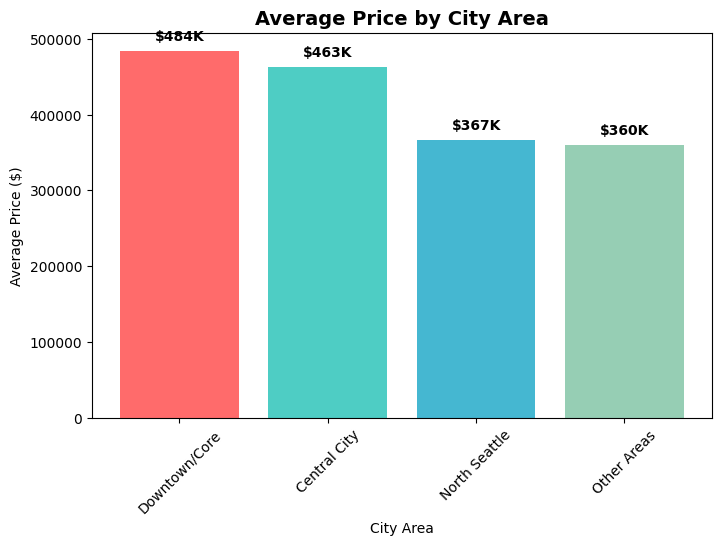

In [109]:
# Chart 2: Average price by city area
area_prices = df_bedroom_city.groupby('city_area')['price'].mean().sort_values(ascending=False)
plt.bar(area_prices.index, area_prices.values, color=colors[:len(area_prices)])
plt.title('Average Price by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Average Price ($)')
plt.xticks(rotation=45)
# Add values on bars
for i, price in enumerate(area_prices.values):
    plt.text(i, price + 10000, f'${price/1000:.0f}K', ha='center', va='bottom', fontweight='bold')

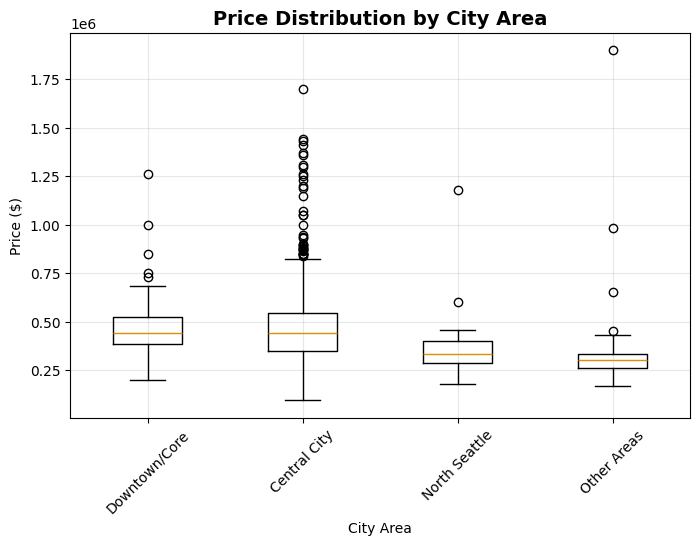

In [110]:
# Chart 3: Price distribution by city area (box plot)
area_data = [df_bedroom_city[df_bedroom_city['city_area'] == area]['price'] for area in area_prices.index]
plt.boxplot(area_data, labels=area_prices.index)
plt.title('Price Distribution by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Price ($)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

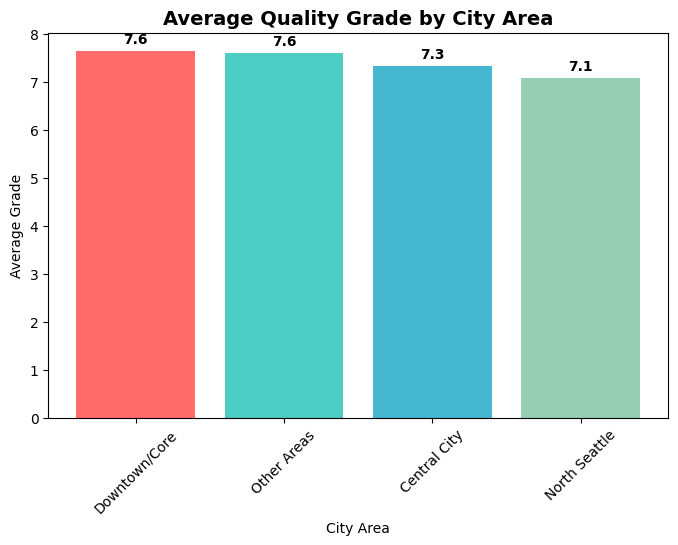

In [111]:
# Chart 5: Quality grade by city area
area_grade = df_bedroom_city.groupby('city_area')['grade'].mean().sort_values(ascending=False)
plt.bar(area_grade.index, area_grade.values, color=colors[:len(area_grade)])
plt.title('Average Quality Grade by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Average Grade')
plt.xticks(rotation=45)
# Add values on bars
for i, grade in enumerate(area_grade.values):
    plt.text(i, grade + 0.1, f'{grade:.1f}', ha='center', va='bottom', fontweight='bold')

Text(0.5, 1.0, 'City Area Distribution')

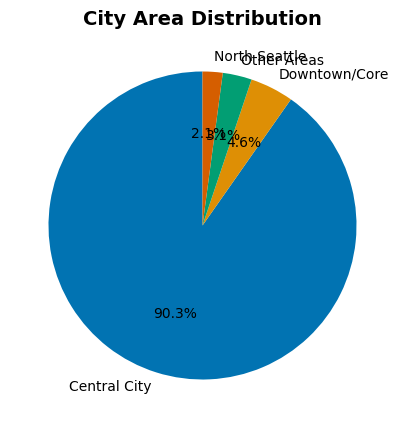

In [112]:
# Chart 6: Pie chart of city area distribution
plt.pie(area_counts.values, labels=area_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('City Area Distribution', fontsize=14, fontweight='bold')

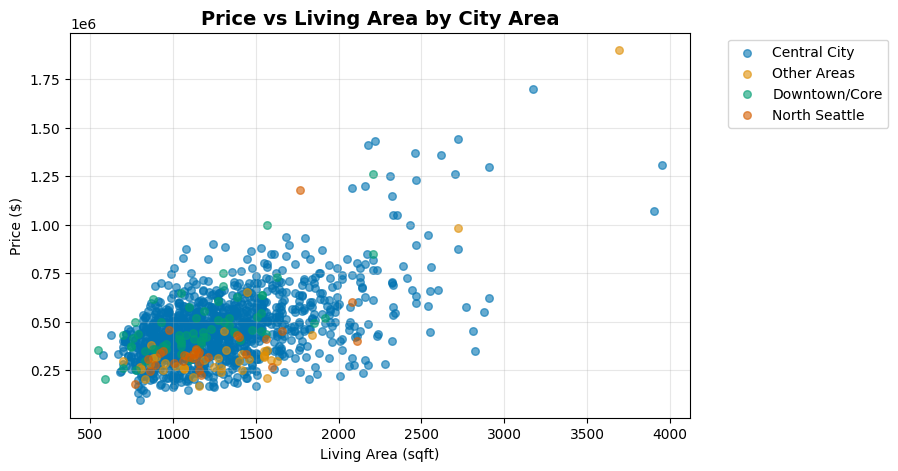

In [113]:
# Chart 9: Scatter plot - Price vs Living Area colored by city area
for area in df_bedroom_city['city_area'].unique():
    subset = df_bedroom_city[df_bedroom_city['city_area'] == area]
    plt.scatter(subset['sqft_living'], subset['price'], alpha=0.6, label=area, s=30)
plt.title('Price vs Living Area by City Area', fontsize=14, fontweight='bold')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

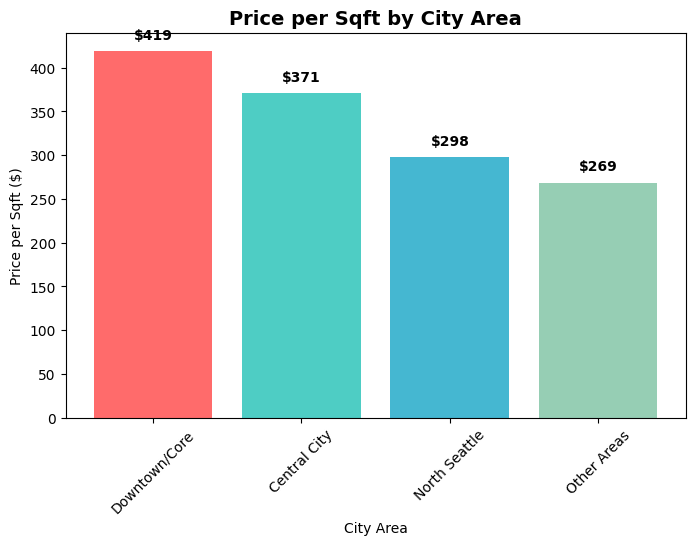

In [114]:
# Chart 6: Price per sqft by city area
df_bedroom_city['price_per_sqft'] = df_bedroom_city['price'] /df_bedroom_city['sqft_living']
area_pps = df_bedroom_city.groupby('city_area')['price_per_sqft'].mean().sort_values(ascending=False)
plt.bar(area_pps.index, area_pps.values, color=colors[:len(area_pps)])
plt.title('Price per Sqft by City Area', fontsize=14, fontweight='bold')
plt.xlabel('City Area')
plt.ylabel('Price per Sqft ($)')
plt.xticks(rotation=45)
# Add values on bars
for i, pps in enumerate(area_pps.values):
    plt.text(i, pps + 10, f'${pps:.0f}', ha='center', va='bottom', fontweight='bold')

In [115]:
# Step 7: Show best value areas
print(f"\n BEST VALUE ANALYSIS:")
print("Areas with good balance of price and quality:")

# Calculate value score (higher grade, lower price per sqft)
area_value = df_bedroom_city.groupby('city_area').agg({
    'price_per_sqft': 'mean',
    'grade': 'mean',
    'price': 'count'
}).round(2)

# Normalize for value score (lower price per sqft and higher grade is better)
area_value['price_per_sqft_norm'] = 1 - (area_value['price_per_sqft'] / area_value['price_per_sqft'].max())
area_value['grade_norm'] = area_value['grade'] / area_value['grade'].max()
area_value['value_score'] = (area_value['price_per_sqft_norm'] + area_value['grade_norm']) / 2

area_value = area_value.sort_values('value_score', ascending=False)
print(area_value[['price_per_sqft', 'grade', 'value_score']])


 BEST VALUE ANALYSIS:
Areas with good balance of price and quality:
               price_per_sqft  grade  value_score
city_area                                        
Other Areas           268.720  7.600        0.677
North Seattle         298.040  7.070        0.608
Central City          370.590  7.320        0.537
Downtown/Core         418.940  7.630        0.500


In [116]:
print(f"\n" + "=" * 60)
print(" CITY AREA ANALYSIS COMPLETE!")
print(f"• Created {len(df_bedroom_city['city_area'].unique())} city area categories")
print(f"• Analyzed {len(df_bedroom_city)} houses across all areas")
print(f"• Best value area: {area_value.index[0]} (score: {area_value['value_score'].iloc[0]:.3f})")
print("=" * 60)


 CITY AREA ANALYSIS COMPLETE!
• Created 4 city area categories
• Analyzed 1377 houses across all areas
• Best value area: Other Areas (score: 0.677)


In [117]:
## We have selected houses that are located in central Seattle because of 
    # Connectivity
    # The grade is 7.3

df_cc = df_bedroom_city[
    (df_bedroom_city['city_area'].isin(['Central City']))]

print(f"Found {len(df_cc)} houses matching your criteria!")


Found 1243 houses matching your criteria!


In [ ]:
# Some criterias to decide on the house:

# Price categories and value assessment
#- Price range: $280K-$468K (Mid-range to Affordable)
#- Price per sqft: $235-$403
#- Price category classification
#- Value for money assessment

In [121]:
print(" PLOTTING HOUSES ACROSS ALL PRICE RANGES")
print("=" * 50)

# Step 1: Show distribution of all price categories
print("  PRICE CATEGORY DISTRIBUTION:")
price_distribution = df_cc['price_category'].value_counts()
total_houses = len(df_cc)

for category, count in price_distribution.items():
    percentage = (count / total_houses) * 100
    print(f"  {category}: {count} houses ({percentage:.1f}%)")

print(f"\n  TOTAL HOUSES: {total_houses}")

 PLOTTING HOUSES ACROSS ALL PRICE RANGES
  PRICE CATEGORY DISTRIBUTION:
  Mid-Range ($400K-$600K): 587 houses (47.2%)
  Affordable ($250K-$400K): 374 houses (30.1%)
  Premium ($600K-$1M): 175 houses (14.1%)
  Budget (<$250K): 89 houses (7.2%)
  Luxury (>$1M): 18 houses (1.4%)

  TOTAL HOUSES: 1243


In [122]:
# Step 2: Basic statistics for each price category
print(f"\n  STATISTICS BY PRICE CATEGORY:")
category_stats = df_cc.groupby('price_category').agg({
    'price': ['count', 'mean', 'min', 'max'],
    'sqft_living': 'mean',
    'bedrooms': 'mean',
    'grade': 'mean'
}).round(2)

# Format the statistics table
category_stats.columns = ['Count', 'Avg_Price', 'Min_Price', 'Max_Price', 'Avg_Living_Area', 'Avg_Bedrooms', 'Avg_Grade']
print(category_stats)


  STATISTICS BY PRICE CATEGORY:
                          Count   Avg_Price   Min_Price   Max_Price  \
price_category                                                        
Budget (<$250K)              89  209892.920   95000.000  248500.000   
Affordable ($250K-$400K)    374  336929.480  250000.000  399950.000   
Mid-Range ($400K-$600K)     587  485328.710  400000.000  599950.000   
Premium ($600K-$1M)         175  701102.430  600000.000  945000.000   
Luxury (>$1M)                18 1265000.000 1000000.000 1700000.000   

                          Avg_Living_Area  Avg_Bedrooms  Avg_Grade  
price_category                                                      
Budget (<$250K)                  1124.820         1.930      7.250  
Affordable ($250K-$400K)         1132.950         1.950      7.190  
Mid-Range ($400K-$600K)          1280.750         1.980      7.270  
Premium ($600K-$1M)              1624.050         1.970      7.590  
Luxury (>$1M)                    2626.670         2.000


  CREATING COMPREHENSIVE PLOTS FOR ALL PRICE RANGES...


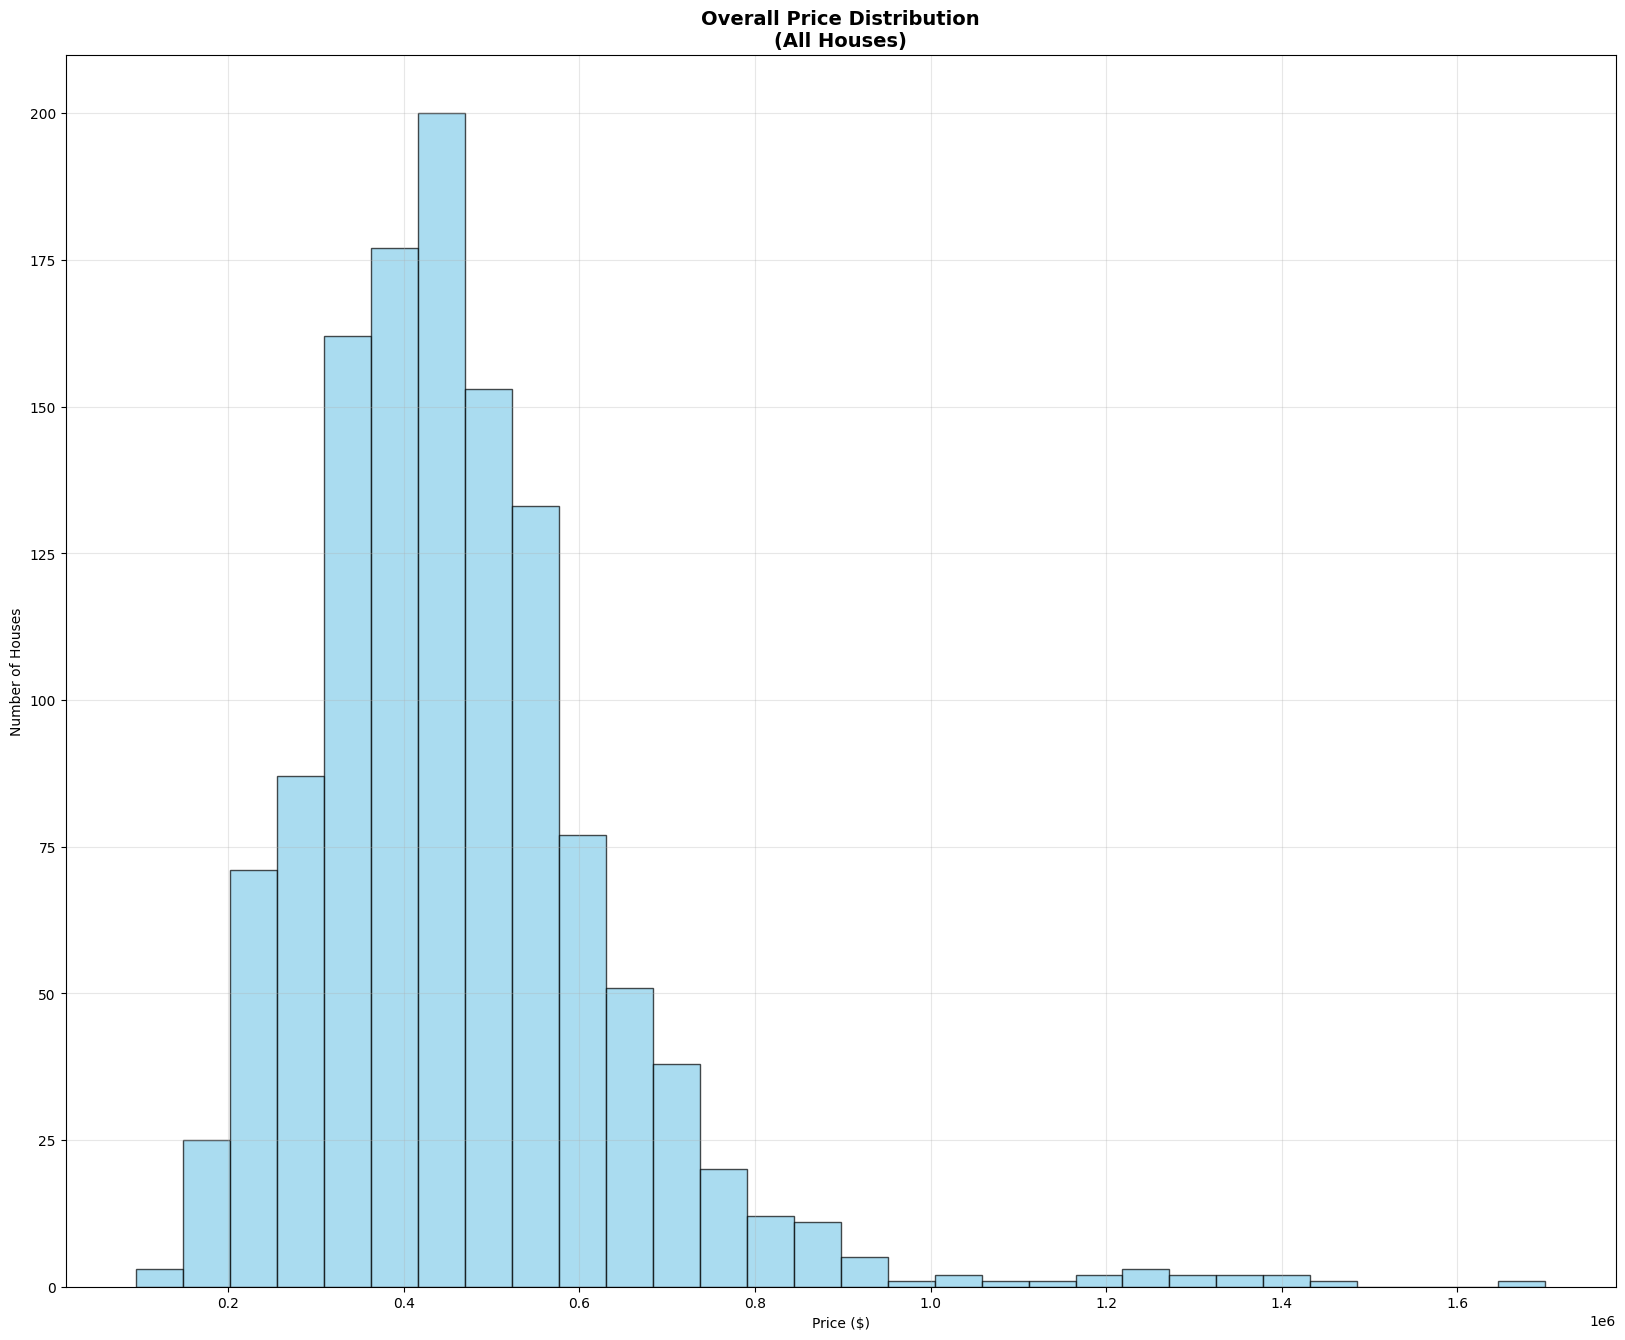

In [123]:
# Step 3: Create comprehensive visualizations for ALL price ranges
print(f"\n  CREATING COMPREHENSIVE PLOTS FOR ALL PRICE RANGES...")

plt.figure(figsize=(20, 16))

# Define colors for each price category
price_colors = {
    'Budget (<$250K)': '#FF6B6B',
    'Affordable ($250K-$400K)': '#4ECDC4',
    'Mid-Range ($400K-$600K)': '#45B7D1',
    'Premium ($600K-$1M)': '#96CEB4',
    'Luxury (>$1M)': '#FECA57'
}

# Chart 1: Price distribution histogram
#plt.subplot(3, 4, 1)
plt.hist(df_cc['price'], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
plt.title('Overall Price Distribution\n(All Houses)', fontsize=14, fontweight='bold')
plt.xlabel('Price ($)')
plt.ylabel('Number of Houses')
plt.grid(True, alpha=0.3)

Text(0.5, 1.0, 'Price Category Distribution')

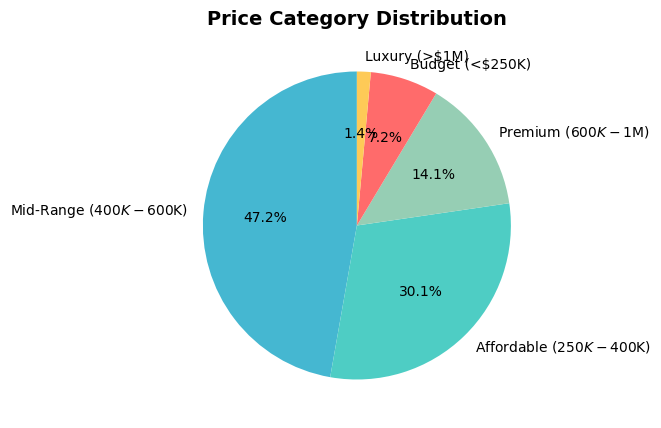

In [124]:
# Chart 2: Price categories pie chart
plt.pie(price_distribution.values, labels=price_distribution.index, 
        autopct='%1.1f%%', startangle=90, colors=[price_colors[cat] for cat in price_distribution.index])
plt.title('Price Category Distribution', fontsize=14, fontweight='bold')


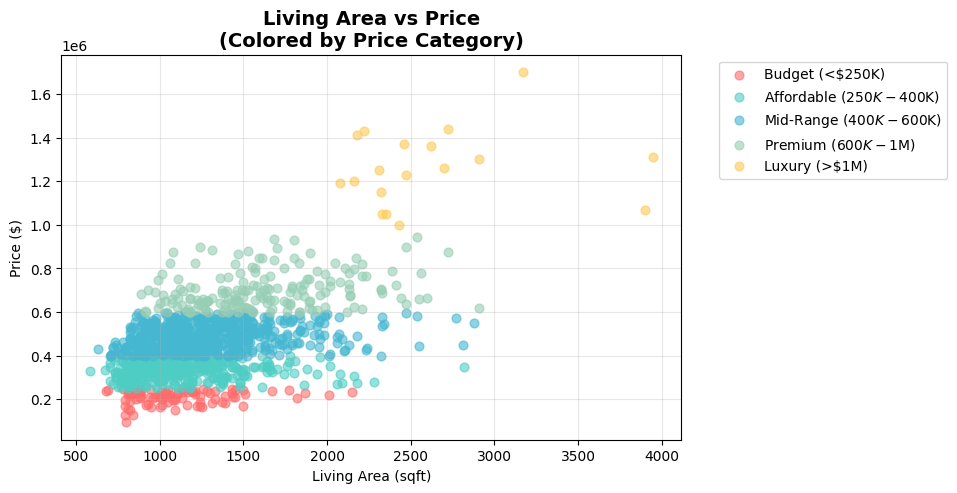

In [125]:
# Chart 3: Price vs Living Area (colored by price category)
for category, color in price_colors.items():
    subset = df_cc[df_cc['price_category'] == category]
    plt.scatter(subset['sqft_living'], subset['price'], 
               label=category, alpha=0.6, s=40, color=color)
plt.title('Living Area vs Price\n(Colored by Price Category)', fontsize=14, fontweight='bold')
plt.xlabel('Living Area (sqft)')
plt.ylabel('Price ($)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)

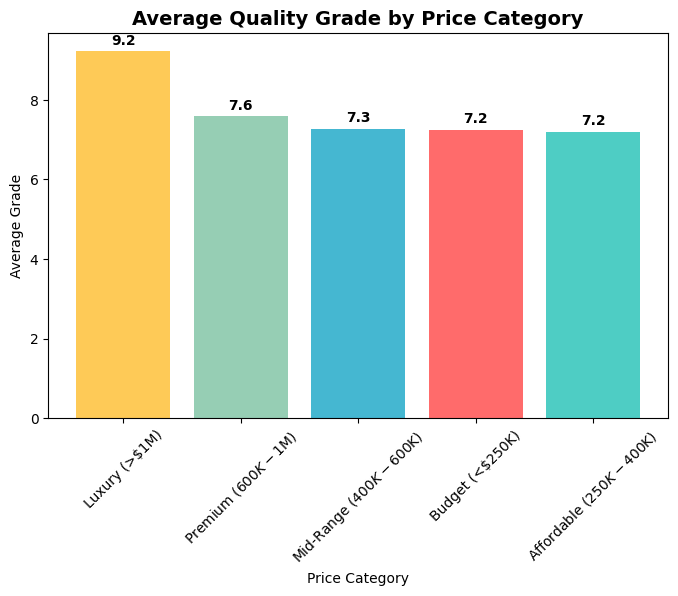

In [126]:
# Chart 6: Average grade by price category
avg_grade_by_price = df_cc.groupby('price_category')['grade'].mean().sort_values(ascending=False)
colors = [price_colors[cat] for cat in avg_grade_by_price.index]
plt.bar(avg_grade_by_price.index, avg_grade_by_price.values, color=colors)
plt.title('Average Quality Grade by Price Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Average Grade')
plt.xticks(rotation=45)
# Add values on bars
for i, grade in enumerate(avg_grade_by_price.values):
    plt.text(i, grade + 0.1, f'{grade:.1f}', ha='center', va='bottom', fontweight='bold')

<module 'matplotlib.pyplot' from '/Users/subhadrachakrabarty/Desktop/neuefrische/ds_ai_bootcamp/project_subhadra/week_03_EDA/ds-EDA-project-sc/.venv/lib/python3.11/site-packages/matplotlib/pyplot.py'>

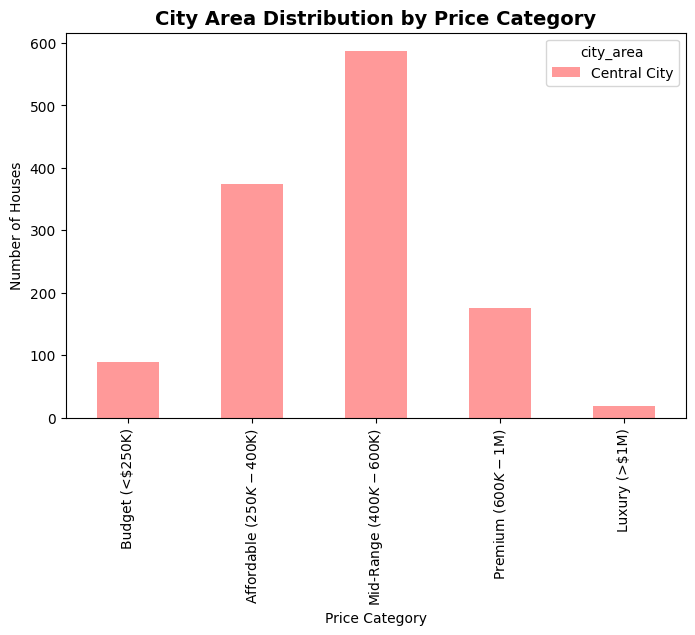

In [127]:
# Chart 9: City area distribution by price category
cross_tab_city = pd.crosstab(df_cc['price_category'], df_cc['city_area'])
cross_tab_city.plot(kind='bar', stacked=True, ax=plt.gca(), 
                   color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99', '#FF99CC', '#C9C9FF'])
plt.title('City Area Distribution by Price Category', fontsize=14, fontweight='bold')
plt.xlabel('Price Category')
plt.ylabel('Number of Houses')
plt

In [129]:
# filter for Budget houses
#df_cc_price = df_cc[df_cc['price_category'].isin(['Budget (<$250K)', 'Affordable ($250K-$400K)'])]
df_cc_price = df_cc[df_cc['price_category'].isin(['Budget (<$250K)'])]

print(f"Found {len(df_cc_price)} houses matching your criteria!")

Found 89 houses matching your criteria!


In [130]:
# Check grade categories
print("Available grade categories in your data:")
print(df_cc_price['grade_category'].unique())

Available grade categories in your data:
['Very Good (9)', 'Good (8)']
Categories (6, object): ['Below Average (1-6)' < 'Average (7)' < 'Good (8)' < 'Very Good (9)' < 'Excellent (10)' < 'Luxury (11+)']


In [132]:
print(df_cc_price.head(5))

          date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
107 2014-07-23 188500.000     2.000      1.750     1240.000  2493.000       1   
505 2014-05-21 240000.000     2.000      1.750     1330.000  7200.000       1   
726 2014-06-13 210000.000     2.000      1.750     1440.000  5680.000       1   
727 2014-09-10 245000.000     2.000      1.000     1050.000  5900.000       1   
902 2014-07-14 200000.000     1.000      1.500     1010.000  1157.000       2   

     waterfront  view  condition  ...  sqft_lot15   price_category  \
107           0     0          4  ...    4966.000  Budget (<$250K)   
505           0     0          3  ...   11682.000  Budget (<$250K)   
726           0     0          4  ...    3547.000  Budget (<$250K)   
727           0     0          3  ...    5900.000  Budget (<$250K)   
902           0     0          3  ...    1688.000  Budget (<$250K)   

     grade_category  bedroom_category         location  month  month_name  \
107   Very Good

In [138]:
# filter for houses in grade: Very good, bedrooms 2 and bathroom >1.5

df_cc_grade = df_cc_price[
    (df_cc_price['grade_category'].str.contains('Very Good')) & 
    (df_cc_price['bedrooms'] == 2) &
    (df_cc_price['bathrooms'] > 1.5)
]
print(f"Found {len(df_cc_grade)} houses matching your criteria!")

print(df_cc_grade.head(2))

Found 9 houses matching your criteria!
          date      price  bedrooms  bathrooms  sqft_living  sqft_lot  floors  \
107 2014-07-23 188500.000     2.000      1.750     1240.000  2493.000       1   
726 2014-06-13 210000.000     2.000      1.750     1440.000  5680.000       1   

     waterfront  view  condition  ...  sqft_lot15   price_category  \
107           0     0          4  ...    4966.000  Budget (<$250K)   
726           0     0          4  ...    3547.000  Budget (<$250K)   

     grade_category  bedroom_category         location  month  month_name  \
107   Very Good (9)        Medium (3)  In Seattle City      7        July   
726   Very Good (9)        Medium (3)  In Seattle City      6        June   

     year     city_area  price_per_sqft  
107  2014  Central City         152.016  
726  2014  Central City         145.833  

[2 rows x 29 columns]


In [139]:
# Sort list by sqft_living (descending) then price (ascending)
sorted_cc = df_cc_grade.sort_values(['sqft_living', 'bathrooms', 'price'], ascending=[False, False, True])

# Display the sorted table
display_columns = ['sqft_living', 'price', 'bedrooms', 'bathrooms', 'grade']
sorted_display = sorted_cc[display_columns].copy()

print(f"\n SORTED TABLE:")
print("=" * 100)
print(sorted_display.to_string(index=False))


 SORTED TABLE:
 sqft_living      price  bedrooms  bathrooms  grade
    1440.000 210000.000     2.000      1.750      8
    1390.000 216500.000     2.000      1.750      8
    1330.000 202200.000     2.000      1.750      8
    1240.000 188500.000     2.000      1.750      8
    1110.000 229800.000     2.000      1.750      8
    1090.000 149900.000     2.000      1.750      8
    1050.000 187000.000     2.000      1.750      8
    1000.000 210000.000     2.000      1.750      8
     850.000 233000.000     2.000      2.250      8


In [144]:
# Selecting top 5 recommendations based on living space
top_city_houses = sorted_cc.head(5)

In [147]:
print(top_city_houses)

            date      price  bedrooms  bathrooms  sqft_living  sqft_lot  \
726   2014-06-13 210000.000     2.000      1.750     1440.000  5680.000   
19180 2014-06-26 216500.000     2.000      1.750     1390.000  4482.000   
8047  2014-09-24 202200.000     2.000      1.750     1330.000  2159.000   

       floors  waterfront  view  condition  ...  sqft_lot15   price_category  \
726         1           0     0          4  ...    3547.000  Budget (<$250K)   
19180       1           0     0          4  ...    4680.000  Budget (<$250K)   
8047        1           0     0          4  ...    3679.000  Budget (<$250K)   

       grade_category  bedroom_category         location  month  month_name  \
726     Very Good (9)        Medium (3)  In Seattle City      6        June   
19180   Very Good (9)        Medium (3)  In Seattle City      6        June   
8047    Very Good (9)        Medium (3)  In Seattle City      9   September   

       year     city_area  price_per_sqft  
726    2014  Cent

In [146]:
# Selecting top 3 recommendations for client
top_city_houses = sorted_cc.head(3)

In [156]:
# Create the map for city houses
print("\n Creating the map...")

# Find the middle point of all houses for centering the map
middle_lat1 =top_city_houses['lat'].mean()
middle_long1 = top_city_houses['long'].mean()

# Create a basic map
city_map = folium.Map(location=[middle_lat1, middle_long1], zoom_start=10)


 Creating the map...


In [157]:
## Mapping recommended city houses
# Map center
middle_lat1 = top_city_houses['lat'].mean()
middle_long1 = top_city_houses['long'].mean()

map_houses1 = folium.Map(location=[middle_lat1, middle_long1], zoom_start=10, tiles='cartodb positron')

# Set bounds
bounds = [
    [top_city_houses['lat'].min(), top_city_houses['long'].min()],
    [top_city_houses['lat'].max(), top_city_houses['long'].max()]
]
map_houses1.fit_bounds(bounds)

# Marker cluster for better visualization
marker_cluster = MarkerCluster().add_to(map_houses1)

def get_marker_color(price_category):
    color_map = {
        'Budget (<$250K)': 'green',
        'Affordable ($250K-$400K)': 'blue', 
        'Mid-Range ($400K-$600K)': 'orange',
        'Premium ($600K-$1M)': 'purple',
        'Luxury (>$1M)': 'red'
    }
    return color_map.get(price_category, 'gray')

# Add markers
for _, row in top_city_houses.iterrows():
    popup_content = f"""
    <div style="width: 250px;">
        <h4>🏠 House Details</h4>
        <hr>
        <b>Price:</b> ${row['price']:,.0f}<br>
        <b>Bedrooms:</b> {row['bedrooms']}<br>
        <b>Bathrooms:</b> {row['bathrooms']}<br>
        <b>Living Area:</b> {row['sqft_living']} sqft<br>
        <b>Grade:</b> {row.get('grade_category', row.get('grade', 'N/A'))}<br>
        <b>Price Category:</b> {row.get('price_category', 'N/A')}<br>
        <b>Year Built:</b> {row['yr_built']}<br>
        <b>Renovated:</b> {'No' if pd.isna(row['yr_renovated']) or row['yr_renovated']==0 else 'Yes'}
    </div>
    """
    price_cat = row.get('price_category', 'Unknown')
    marker_color = get_marker_color(price_cat)

    folium.Marker(
        location=[row['lat'], row['long']],
        tooltip=f"${row['price']:,.0f} | {row['bedrooms']} bed | Grade: {row.get('grade_category', row.get('grade', 'N/A'))}",
        popup=folium.Popup(popup_content, max_width=300),
        icon=folium.Icon(color=marker_color, icon='home')
    ).add_to(marker_cluster)

print(f" Added {len(top_city_houses)} house markers")

# Add legend
"""legend_html = '''
<div style="position: fixed; 
     bottom: 50px; left: 50px; width: 200px; height: 180px; 
     background-color: white; border:2px solid grey; z-index:9999; 
     font-size:14px; padding: 10px">
     <p><strong>🏠 Price Legend</strong></p>
     <p><span style="color: green;">●</span> Budget (<$250K)</p>
     <p><span style="color: blue;">●</span> Affordable ($250K-$400K)</p>
     <p><span style="color: orange;">●</span> Mid-Range ($400K-$600K)</p>
     <p><span style="color: purple;">●</span> Premium ($600K-$1M)</p>
     <p><span style="color: red;">●</span> Luxury (>$1M)</p>
</div>
'''
"""
#map_houses.get_root().html.add_child(folium.Element(legend_html))

# Save map
map_houses1.save("city_house_locations.html")
print(" Map saved as 'city_house_locations.html'")


 Added 3 house markers
 Map saved as 'city_house_locations.html'


In [158]:
# Add house markers to the map
print("Adding house markers to map...")

# Colors for different locations
colors = {
    "In Seattle City": "blue",
    "Outside Seattle": "red"
}

# Icons for different locations
icons = {
    "In Seattle City": "home",
    "Outside Seattle": "globe"
}

for index, house in medium_houses.iterrows():
    # Create a popup with house information
    popup_text = f"""
    <b>Location:</b> {house['location']}<br>
    <b>Price:</b> ${house['price']:,.0f}<br>
    <b>Zipcode:</b> {int(house['zipcode'])}<br>
    <b>Bedrooms:</b> {int(house['bedrooms'])}<br>
    <b>Bathrooms:</b> {house['bathrooms']}<br>
    <b>Size:</b> {int(house['sqft_living'])} sqft
    """
    
    # Add marker to map
    folium.Marker(
        location=[house['lat'], house['long']],
        popup=folium.Popup(popup_text, max_width=250),
        tooltip=f"${house['price']:,.0f} - {house['location']}",
        icon=folium.Icon(
            color=colors[house['location']],
            icon=icons[house['location']],
            prefix='fa'
        )
    ).add_to(map_houses1)


Adding house markers to map...


In [ ]:
"""
# Add a legend to the map
print(" Adding legend...")

legend_html = '''
<div style="position: fixed; 
            top: 10px; left: 50px; width: 200px; 
            background: white; border: 2px solid grey; 
            padding: 10px; font-size: 14px; z-index: 9999;">
    <h4 style="margin: 0 0 8px 0;">House Locations</h4>
    <p style="margin: 2px 0;">
        <i class="fa fa-home" style="color: blue"></i> In Seattle City
    </p>
    <p style="margin: 2px 0;">
        <i class="fa fa-globe" style="color: red"></i> Outside Seattle
    </p>
</div>
'''

#map_houses1.get_root().html.add_child(folium.Element(legend_html))
"""

SyntaxError: incomplete input (1144845274.py, line 1)

In [159]:
# Save the map
## This is a HUGE image with too many points
map_houses1.save("city_house_locations.html")

# configure chrome
options = Options()
options.add_argument("--headless")
driver = webdriver.Chrome(options=options)

# load the html
#driver.get("country_house_locations.html")
#time.sleep(3)   # wait for map tiles to load

# save screenshot
#driver.save_screenshot("map.png")
#driver.quit()
print(" Map saved as 'city_house_locations.html'")


 Map saved as 'city_house_locations.html'
